# Linguistic Variation in AI Subreddit Communities

**Authors:** Mounami Kayitha, Varun Sardana, Prithvi Rao, Gabor Szita, Sristhi Thapar  
**Course:** PSTAT 134, Statistical Data Science

In [1]:
import os
from pathlib import Path

# Set working directory to project root — runs once for the entire notebook
_notebook_dir = Path().resolve()
_project_root = _notebook_dir.parent if _notebook_dir.name == 'notebooks' else _notebook_dir
os.chdir(_project_root)
print('Working directory:', os.getcwd())

# Skip live Reddit API calls if the dataset is already collected
_SKIP_COLLECTION = Path('data/reddit_ai_posts_CLEAN.csv').exists()
print(f'Dataset already collected: {_SKIP_COLLECTION}')

Working directory: /Users/varunsardana/PSTAT-134-Final-Project
Dataset already collected: True


---

# Section 1 — Data Collection

---

In [2]:
import requests
import pandas as pd
import time

In [3]:
headers = {"User-Agent": "pstat134project/1.0 (academic research)"}

# The 4 subreddits we are collecting from
subreddits = ["technology", "artificial", "singularity", "MachineLearning"]

# Keep the class size balanced so each subreddit contributes about the same number of posts.
POSTS_PER_SUB = 200

In [4]:
def get_posts(subreddit, limit=200):
    posts = []
    after = None
    
    while len(posts) < limit:
        url = f"https://www.reddit.com/r/{subreddit}/top.json?limit=100&t=year"
        if after:
            url += f"&after={after}"
            
        response = requests.get(url, headers=headers)
        data = response.json()
        
        children = data["data"]["children"]
        if not children:
            break
            
        for post in children:
            p = post["data"]
            posts.append({
                "id":           p["id"],
                "title":        p["title"],
                "selftext":     p["selftext"],
                "upvote_ratio": p["upvote_ratio"],
                "num_comments": p["num_comments"],
                "is_self":      p["is_self"],
                "edited":       p["edited"],
                "created_utc":  p["created_utc"],
                "subreddit":    p["subreddit"]
            })
        
        after = data["data"]["after"]
        if not after:
            break
            
        time.sleep(1)  # sleep 1 sec to be polite to Reddit's servers
    
    return posts[:limit]

In [5]:
if not _SKIP_COLLECTION:
    all_posts = []

    for sub in subreddits:
        print(f"Collecting from r/{sub}...")
        posts = get_posts(sub, POSTS_PER_SUB)
        all_posts.extend(posts)
        print(f"  Got {len(posts)} posts")
        time.sleep(2)

    print(f"\nTotal posts collected: {len(all_posts)}")
else:
    print('Skipped — data already collected')

Skipped — data already collected


In [6]:
if not _SKIP_COLLECTION:
    df = pd.DataFrame(all_posts)
    # Preview it
    print(df.shape)
    print(df["subreddit"].value_counts())
    df.head()
else:
    print('Skipped — data already collected')

Skipped — data already collected


In [7]:
if not _SKIP_COLLECTION:
    # Save raw data to CSV
    df.to_csv("data/raw/reddit_raw.csv", index=False)
    print("Saved to data/raw/reddit_raw.csv")
else:
    print('Skipped — data already collected')

Skipped — data already collected


In [8]:
if not _SKIP_COLLECTION:
    missing_body = df[df["selftext"].isin(["", "[removed]", "[deleted]"])]
    print(f"Posts with missing/removed body text: {len(missing_body)}")
    print(f"\nMissing by subreddit:")
    print(missing_body["subreddit"].value_counts())
else:
    print('Skipped — data already collected')

Skipped — data already collected


## Data Collection Summary

- **API:** Reddit public JSON API
- **Subreddits we used:** r/MachineLearning, r/artificial, r/singularity, r/Futurology
- **Endpoints:** top/year, top/all, hot, controversial/year
- **Filter:** self-text posts ≥20 words, duplicates removed by post ID
- **Output File:** `data/reddit_ai_posts_CLEAN.csv` — 2,927 posts

## Part 2 — Expanding From What We Know

The initial scrape hit Reddit's ~250-post endpoint due to which we were unable to collect more posts. To grow the dataset we go through three additional endpoints per subreddit, filter for posts with body text, check for duplication against already-collected IDs, and then add.

In [9]:
import os
import requests
import pandas as pd
import numpy as np
import time
from datetime import datetime
from pathlib import Path

# Fix working directory — same pattern used in notebooks 02, 03, 04
notebook_dir = Path().resolve()
project_root = notebook_dir.parent if notebook_dir.name == 'notebooks' else notebook_dir
os.chdir(project_root)
print('Working directory:', os.getcwd())

SUBREDDITS    = ["MachineLearning", "artificial", "singularity", "Futurology"]
HEADERS       = {"User-Agent": "pstat134project/2.0 (academic research)"}
LIMIT_PER_REQ = 100
TARGET_PER_ENDPOINT = 250

NEW_ENDPOINTS = [
    ("top",          "all"),
    ("hot",          None),
    ("controversial","year"),
]

BAD_SELFTEXT = {"", "[removed]", "[deleted]"}

def fetch_listing(subreddit, sort, timeframe=None, target=TARGET_PER_ENDPOINT):
    posts = []
    after = None
    while len(posts) < target:
        url = f"https://www.reddit.com/r/{subreddit}/{sort}.json?limit={LIMIT_PER_REQ}"
        if timeframe:
            url += f"&t={timeframe}"
        if after:
            url += f"&after={after}"
        try:
            resp = requests.get(url, headers=HEADERS, timeout=15)
            if resp.status_code == 429:
                print(f"    Rate-limited — sleeping 30s...")
                time.sleep(30)
                continue
            if resp.status_code != 200:
                print(f"    HTTP {resp.status_code} — skipping")
                break
            data = resp.json()
        except Exception as e:
            print(f"    Error: {e} — skipping")
            break
        children = data.get("data", {}).get("children", [])
        if not children:
            break
        for child in children:
            posts.append(child["data"])
        after = data["data"].get("after")
        if not after or len(posts) >= target:
            break
        time.sleep(1.2)
    return posts[:target]

def build_row(p, subreddit):
    selftext = p.get("selftext", "") or ""
    title    = p.get("title", "")   or ""
    has_body = selftext.strip() not in BAD_SELFTEXT and len(selftext.strip()) > 0
    text     = (title + " " + selftext).strip() if has_body else title
    created_utc = p.get("created_utc", 0)
    try:
        created_dt = datetime.utcfromtimestamp(created_utc).strftime("%Y-%m-%d %H:%M:%S")
    except:
        created_dt = ""
    return {
        "id":             p.get("id", ""),
        "subreddit":      subreddit,
        "title":          title,
        "selftext":       selftext,
        "text":           text,
        "text_word_count": len(text.split()),
        "has_body":       has_body,
        "upvote_ratio":   p.get("upvote_ratio", np.nan),
        "num_comments":   p.get("num_comments", 0),
        "score":          p.get("score", 0),
        "is_self":        p.get("is_self", False),
        "edited":         p.get("edited", False),
        "created_utc":    created_utc,
        "created_dt":     created_dt,
        "url":            p.get("url", ""),
        "permalink":      p.get("permalink", ""),
    }

print("Functions defined. Ready to collect.")

Working directory: /Users/varunsardana/PSTAT-134-Final-Project
Functions defined. Ready to collect.


In [10]:
if not _SKIP_COLLECTION:
    import os
    from pathlib import Path

    notebook_dir = Path().resolve()
    project_root = notebook_dir.parent if notebook_dir.name == 'notebooks' else notebook_dir
    os.chdir(project_root)
    print('Working directory:', os.getcwd())

    existing_df  = pd.read_csv("data/reddit_ai_posts_CLEAN.csv")
    existing_ids = set(existing_df["id"].astype(str))
    print(f"Existing dataset: {len(existing_df)} posts, {len(existing_ids)} unique IDs")
    print(f"Current counts per subreddit:")
    print(existing_df["subreddit"].value_counts().to_string())
    print()
    new_rows = []

    for sub in SUBREDDITS:
        sub_new = 0
        for sort, timeframe in NEW_ENDPOINTS:
            label = f"{sort}/{timeframe}" if timeframe else sort
            print(f"  r/{sub} — {label} ...", end=" ", flush=True)

            raw_posts = fetch_listing(sub, sort, timeframe)
            added = 0

            for p in raw_posts:
                pid = str(p.get("id", ""))
                if pid in existing_ids:
                    continue

                row = build_row(p, sub)

                if not row["has_body"]:
                    continue
                if row["text_word_count"] < 20:
                    continue

                new_rows.append(row)
                existing_ids.add(pid)
                added += 1
                sub_new += 1

            print(f"{added} new posts with body text")
            time.sleep(2)

        print(f"  → r/{sub} total new: {sub_new}")
        print()

    print(f"Total new posts collected: {len(new_rows)}")
else:
    print('Skipped — data already collected')

Skipped — data already collected


In [11]:
if not _SKIP_COLLECTION:
    new_df     = pd.DataFrame(new_rows)
    combined   = pd.concat([existing_df, new_df], ignore_index=True)

    combined   = combined.drop_duplicates(subset="id", keep="first")

    combined   = combined.sort_values(["subreddit", "created_utc"]).reset_index(drop=True)

    print("=== Combined Dataset ===")
    print(f"Total posts : {len(combined)}")
    print(f"New posts   : {len(new_df)}")
    print()
    print("Posts per subreddit (before → after):")
    before = existing_df["subreddit"].value_counts()
    after  = combined["subreddit"].value_counts()
    for sub in ["MachineLearning", "artificial", "singularity", "Futurology"]:
        b = before.get(sub, 0)
        a = after.get(sub, 0)
        gain = a - b
        print(f"  {sub:20s}: {b:4d}  →  {a:4d}  (+{gain})")

    print("Word count stats on new posts:")
    print(new_df["text_word_count"].describe().round(1).to_string())
else:
    print('Skipped — data already collected')

Skipped — data already collected


In [12]:
if not _SKIP_COLLECTION:
    output_path = Path("data/reddit_ai_posts_CLEAN.csv")
    combined.to_csv(output_path, index=False)
    print(f"Saved expanded dataset to {output_path}")
    print(f"Total posts: {len(combined)}")

else:
    print('Skipped — data already collected')

Skipped — data already collected


In [13]:
import pandas as pd
_df_check = pd.read_csv('data/reddit_ai_posts_CLEAN.csv')
print(f'Dataset loaded: {len(_df_check)} posts across {_df_check["subreddit"].nunique()} subreddits')
print(_df_check['subreddit'].value_counts())

Dataset loaded: 2927 posts across 4 subreddits
subreddit
MachineLearning    984
artificial         782
Futurology         583
singularity        578
Name: count, dtype: int64


---

# Section 2 — Data Cleaning & Exploratory Data Analysis

---

In [14]:
import os
from pathlib import Path


notebook_dir = Path().resolve()
project_root = notebook_dir.parent if notebook_dir.name == "notebooks" else notebook_dir
os.chdir(project_root) # keep paths relative

print("Working directory:", os.getcwd())

Working directory: /Users/varunsardana/PSTAT-134-Final-Project


In [15]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import nltk
from collections import Counter
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import TfidfVectorizer

nltk.download("stopwords", quiet=True)
nltk.download("wordnet", quiet=True)
nltk.download("punkt", quiet=True)

# consistent colors for each subreddit
PALETTE = {
    "MachineLearning": "#4C72B0",
    "artificial":      "#DD8452",
    "singularity":     "#55A868",
    "Futurology":      "#C44E52",
}
SUB_ORDER = ["MachineLearning", "artificial", "singularity", "Futurology"]

# shared plot style
sns.set_theme(style="whitegrid", font_scale=1.1) # default style
plt.rcParams["figure.dpi"] = 110

In [16]:
df = pd.read_csv("data/reddit_ai_posts_CLEAN.csv", parse_dates=["created_dt"])

print(f"Dataset shape : {df.shape[0]} posts x {df.shape[1]} columns")
print(f"Date range    : {df['created_dt'].min().date()} → {df['created_dt'].max().date()}")
print()
print("Posts per subreddit:")
print(df["subreddit"].value_counts())
print()
print(df.head(3))

Dataset shape : 2927 posts x 16 columns
Date range    : 2016-07-29 → 2026-05-26

Posts per subreddit:
subreddit
MachineLearning    984
artificial         782
Futurology         583
singularity        578
Name: count, dtype: int64

        id   subreddit                                              title  \
0  101f9z4  Futurology  Pulling together different technologies to mak...   
1  10ehigz  Futurology  Hello, I am Hassan Ragab. I am an interdiscipl...   
2  10s52md  Futurology  I finally think the concept of AGI is misleadi...   

                                            selftext  \
0  Here are some fascinating articles and links a...   
1  I'm an Egyptian-born U.S.-based architect and ...   
2  TL;DR: (and it's long) What I am trying to arg...   

                                                text  text_word_count  \
0  Pulling together different technologies to mak...              204   
1  Hello, I am Hassan Ragab. I am an interdiscipl...              143   
2  I finally thi

In [17]:

df["text"] = df["text"].fillna("")

In [18]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"[^a-z\s]", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

df["full_text"] = df["text"].apply(clean_text)

In [ ]:
stop_words = set(stopwords.words("english")) # removing the repeated and unecessary words from the words which are called stop words 
lemmatizer = WordNetLemmatizer() # getting the words to their base form here called lemma

def preprocess(text):
    tokens = text.split()
    tokens = [t for t in tokens if t not in stop_words]
    tokens = [lemmatizer.lemmatize(t) for t in tokens]
    return " ".join(tokens)

df["full_text"] = df["full_text"].apply(preprocess)
print("Sample preprocessed text:")
print(df["full_text"].iloc[0][:200])

Sample preprocessed text:
pulling together different technology make interstellar colonization possible fascinating article link seemingly unrelated technology baby born year frozen embryo seed thousand year old able sprout gr


We removes common English stopwords plus a custom list of Reddit words we personally want to remove("like", "just", "going") that appear across all four subreddits but carry no value to us.

Then we perform Lemmatization which essentially maps words to their base form so "running" and "runs" count as the same token.

In [20]:
before = len(df)
df = df[df["full_text"].apply(lambda x: len(x.split()) >= 3)]
after = len(df)
print(f"Rows before filter : {before}")
print(f"Rows after filter  : {after}  (dropped {before - after})")
print()
print("Posts per subreddit after cleaning:")
print(df["subreddit"].value_counts())

Rows before filter : 2927
Rows after filter  : 2927  (dropped 0)

Posts per subreddit after cleaning:
subreddit
MachineLearning    984
artificial         782
Futurology         583
singularity        578
Name: count, dtype: int64


## Section 1 — Dataset Overview

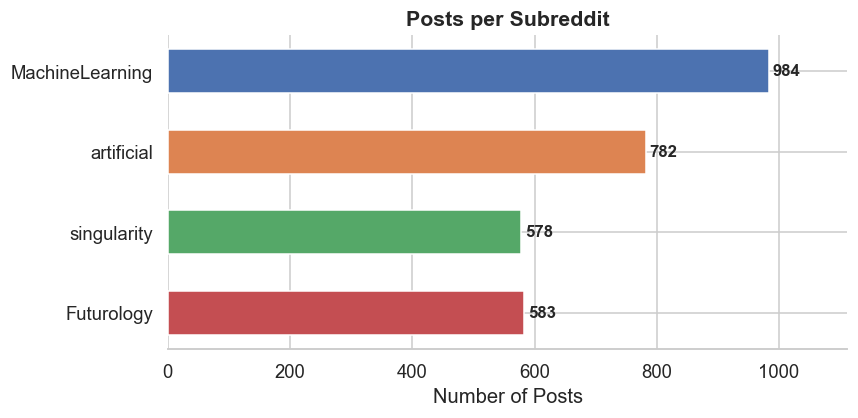

In [21]:
counts = df["subreddit"].value_counts().reindex(SUB_ORDER)
colors = [PALETTE[s] for s in SUB_ORDER]

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(SUB_ORDER, counts.values, color=colors, edgecolor="white", height=0.55)

for bar, val in zip(bars, counts.values):
    ax.text(bar.get_width() + 6, bar.get_y() + bar.get_height() / 2,
            str(val), va="center", fontsize=11, fontweight="bold")

ax.set_xlabel("Number of Posts")
ax.set_title("Posts per Subreddit", fontsize=14, fontweight="bold")
ax.set_xlim(0, max(counts.values) * 1.13)
ax.invert_yaxis()
sns.despine(left=True)
plt.tight_layout()
plt.show()

MachineLearning (984 posts) has roughly 1.7× more posts than singularity (578). A  classifier that always predicts MachineLearning would hit **33.6% accuracy** which is our baseline to beat.

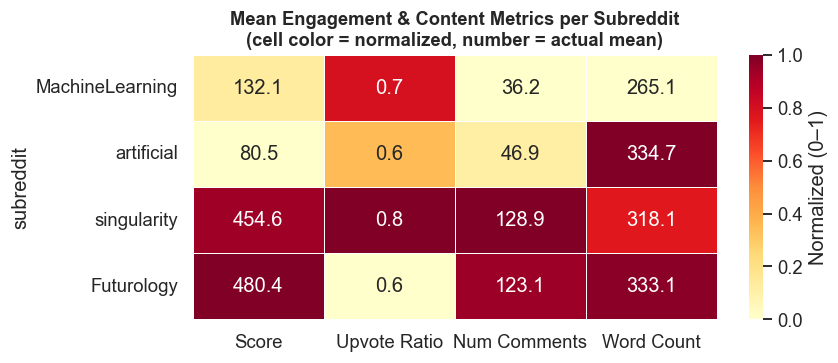

In [22]:
cols  = ["score", "upvote_ratio", "num_comments", "text_word_count"]
labels = ["Score", "Upvote Ratio", "Num Comments", "Word Count"]

summary    = df.groupby("subreddit")[cols].mean().reindex(SUB_ORDER)
normalized = (summary - summary.min()) / (summary.max() - summary.min())

fig, ax = plt.subplots(figsize=(8, 3.5))
sns.heatmap(
    normalized, annot=summary.round(1), fmt="g",
    cmap="YlOrRd", linewidths=0.6, ax=ax,
    cbar_kws={"label": "Normalized (0–1)"}
 )
ax.set_title(
    "Mean Engagement & Content Metrics per Subreddit\n"
    "(cell color = normalized, number = actual mean)",
    fontsize=12, fontweight="bold"
 )
ax.set_xticklabels(labels, rotation=0)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
plt.tight_layout()
plt.show()

Cell color is normalized 0–1 for cross-metric comparison. Over here the number is the actual mean. 

MachineLearning scores lowest on word count but highest on upvote ratio which means that its shorter but with more more agreed-upon posts.

## Section 2 — Post Length & Content Richness

/var/folders/t2/_lp651dj2b1fcvgx6gpfll6w0000gn/T/ipykernel_8937/4048682895.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


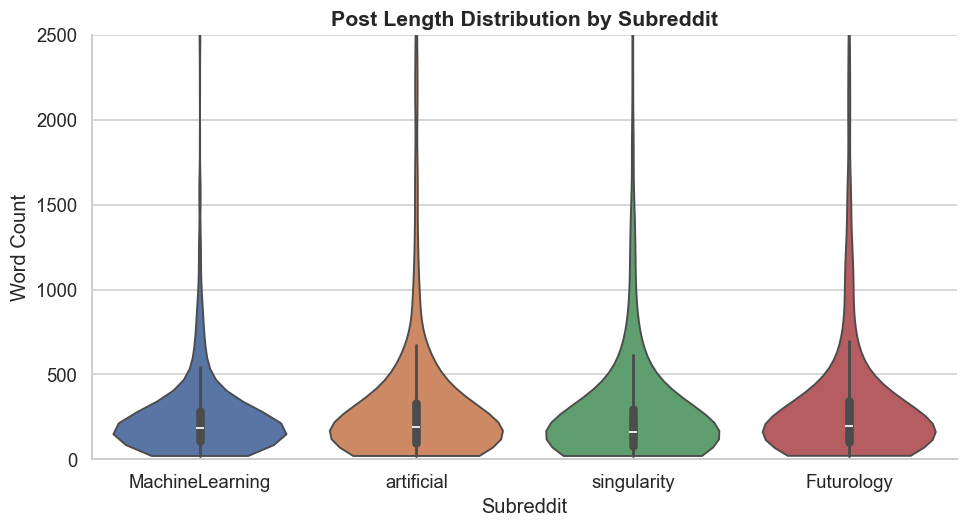

In [23]:
# Plot 3 is word count violin
fig, ax = plt.subplots(figsize=(9, 5))

sns.violinplot(
    data=df, x="subreddit", y="text_word_count",
    order=SUB_ORDER,
    palette=PALETTE,
    inner="box",
    cut=0,
    ax=ax
)

ax.set_title("Post Length Distribution by Subreddit", fontsize=14, fontweight="bold")
ax.set_xlabel("Subreddit")
ax.set_ylabel("Word Count")
ax.set_ylim(0, 2500)
sns.despine()
plt.tight_layout()
plt.show()

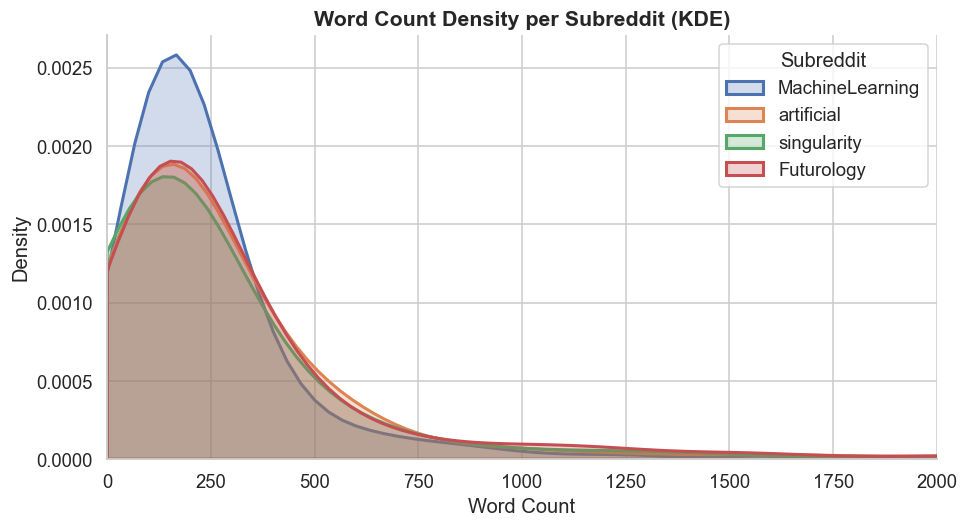

In [24]:
# Plot 4 — word count KDE
fig, ax = plt.subplots(figsize=(9, 5))

for sub in SUB_ORDER:
    subset = df[df["subreddit"] == sub]["text_word_count"]
    sns.kdeplot(
        subset,
        ax=ax,
        label=sub,
        color=PALETTE[sub],
        fill=True,
        alpha=0.25,
        linewidth=2,
        clip=(0, None)
    )

ax.set_title("Word Count Density per Subreddit (KDE)", fontsize=14, fontweight="bold")
ax.set_xlabel("Word Count")
ax.set_ylabel("Density")
ax.set_xlim(0, 2000)
ax.legend(title="Subreddit")
sns.despine()
plt.tight_layout()
plt.show()

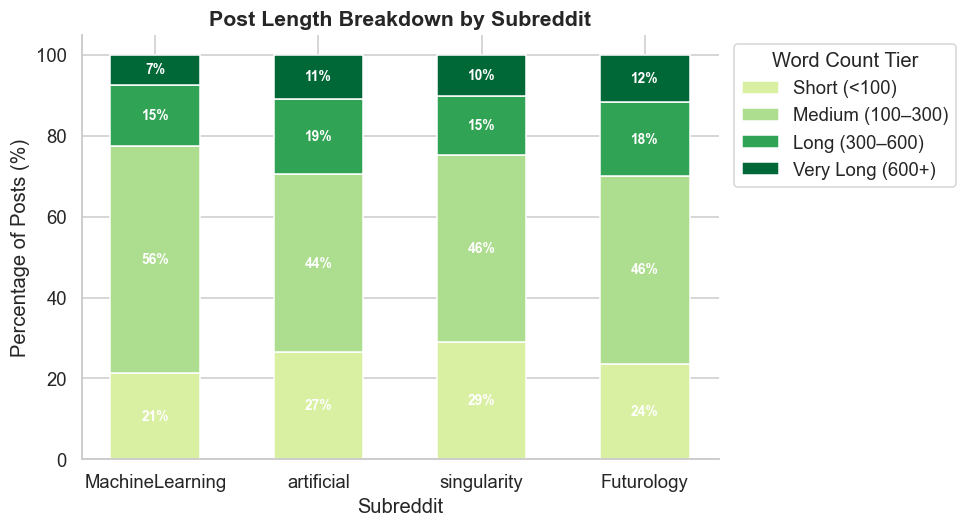

In [25]:
# Plot 5 is a word count buckets: this gives us the proportion of short/medium/long/very long posts per subreddit
def bucket(wc):
    if wc < 100:   return "Short (<100)"
    if wc < 300:   return "Medium (100–300)"
    if wc < 600:   return "Long (300–600)"
    return             "Very Long (600+)"

bucket_order  = ["Short (<100)", "Medium (100–300)", "Long (300–600)", "Very Long (600+)"]
bucket_colors = ["#d9f0a3", "#addd8e", "#31a354", "#006837"]

df["wc_bucket"] = df["text_word_count"].apply(bucket)

bucket_pct = (
    df.groupby(["subreddit", "wc_bucket"])
    .size()
    .unstack(fill_value=0)
    .reindex(SUB_ORDER)[bucket_order]
)
bucket_pct = bucket_pct.div(bucket_pct.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(9, 5))
bottom = np.zeros(len(SUB_ORDER))

for col, color in zip(bucket_order, bucket_colors):
    vals = bucket_pct[col].values
    bars = ax.bar(SUB_ORDER, vals, bottom=bottom, label=col, color=color, edgecolor="white", width=0.55)
    for bar, val in zip(bars, vals):
        if val > 5:
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_y() + bar.get_height() / 2,
                f"{val:.0f}%", ha="center", va="center", fontsize=9, fontweight="bold", color="white"
            )
    bottom += vals

ax.set_title("Post Length Breakdown by Subreddit", fontsize=14, fontweight="bold")
ax.set_ylabel("Percentage of Posts (%)")
ax.set_xlabel("Subreddit")
ax.set_ylim(0, 105)
ax.legend(title="Word Count Tier", bbox_to_anchor=(1.01, 1), loc="upper left")
sns.despine()
plt.tight_layout()
plt.show()

## Section 3 — Other Important Metrics

/var/folders/t2/_lp651dj2b1fcvgx6gpfll6w0000gn/T/ipykernel_8937/2003931496.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


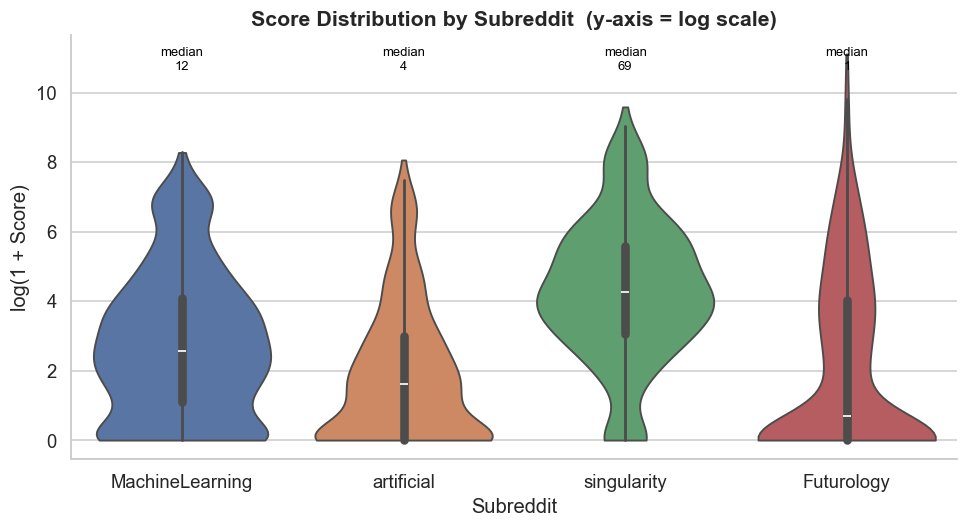

In [26]:
# log1p keeps zeros valid
df["log_score"] = np.log1p(df["score"])

fig, ax = plt.subplots(figsize=(9, 5))
sns.violinplot(
    data=df, x="subreddit", y="log_score",
    order=SUB_ORDER, palette=PALETTE,
    inner="box", cut=0, ax=ax
)

# show median score
for i, sub in enumerate(SUB_ORDER):
    med = df[df["subreddit"] == sub]["score"].median()
    ax.text(i, ax.get_ylim()[1] * 0.97, f"median\n{int(med)}",
            ha="center", va="top", fontsize=8.5, color="black")

ax.set_title("Score Distribution by Subreddit  (y-axis = log scale)", fontsize=14, fontweight="bold")
ax.set_xlabel("Subreddit")
ax.set_ylabel("log(1 + Score)")
sns.despine()
plt.tight_layout()
plt.show()

/var/folders/t2/_lp651dj2b1fcvgx6gpfll6w0000gn/T/ipykernel_8937/1953040556.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


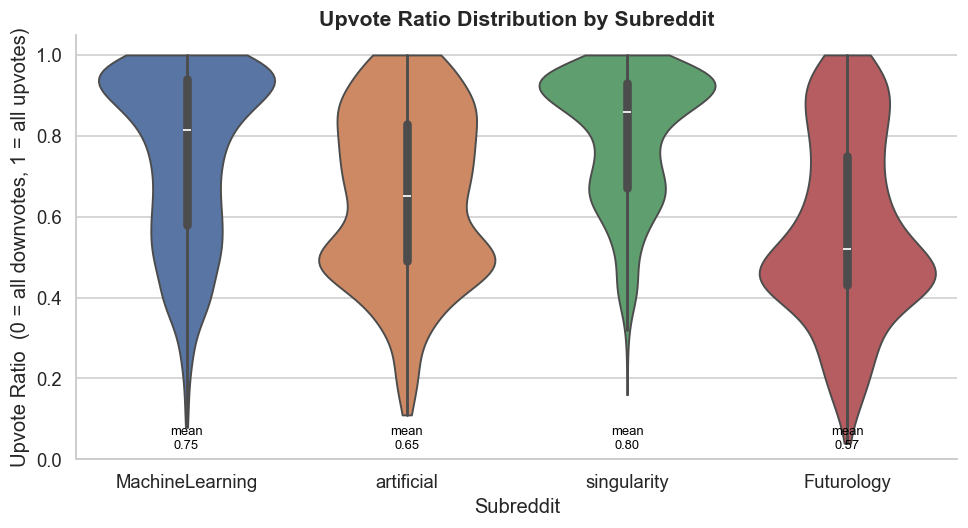

In [27]:
# Plot 7 — Plotting the violin graph for upvote ratios
fig, ax = plt.subplots(figsize=(9, 5))
sns.violinplot(
    data=df, x="subreddit", y="upvote_ratio",
    order=SUB_ORDER, palette=PALETTE,
    inner="box", cut=0, ax=ax
)

# show mean ratio
for i, sub in enumerate(SUB_ORDER):
    mean_val = df[df["subreddit"] == sub]["upvote_ratio"].mean()
    ax.text(i, 0.02, f"mean\n{mean_val:.2f}",
            ha="center", va="bottom", fontsize=8.5, color="black")

ax.set_title("Upvote Ratio Distribution by Subreddit", fontsize=14, fontweight="bold")
ax.set_xlabel("Subreddit")
ax.set_ylabel("Upvote Ratio  (0 = all downvotes, 1 = all upvotes)")
ax.set_ylim(0, 1.05)
sns.despine()
plt.tight_layout()
plt.show()

We get some important results from here. singularity and MachineLearning group near 1.0 which means that communities largely agree on what gets upvoted.


Futurology's wide low-spread violin shows more controversial content.

/var/folders/t2/_lp651dj2b1fcvgx6gpfll6w0000gn/T/ipykernel_8937/2854102616.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


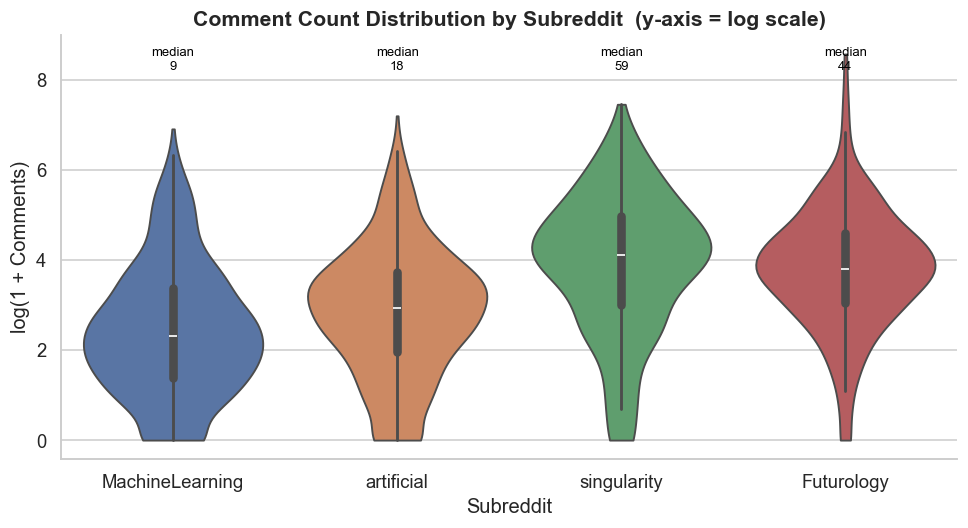

In [28]:
# Plot 8 - comment count violin
df["log_comments"] = np.log1p(df["num_comments"])

fig, ax = plt.subplots(figsize=(9, 5))
sns.violinplot(
    data=df, x="subreddit", y="log_comments",
    order=SUB_ORDER, palette=PALETTE,
    inner="box", cut=0, ax=ax
)

# show median comments
for i, sub in enumerate(SUB_ORDER):
    med = df[df["subreddit"] == sub]["num_comments"].median()
    ax.text(i, ax.get_ylim()[1] * 0.97, f"median\n{int(med)}",
            ha="center", va="top", fontsize=8.5, color="black")

ax.set_title("Comment Count Distribution by Subreddit  (y-axis = log scale)", fontsize=14, fontweight="bold")
ax.set_xlabel("Subreddit")
ax.set_ylabel("log(1 + Comments)")
sns.despine()
plt.tight_layout()
plt.show()

Futurology causes the most discussion (median 34 comments) vs MachineLearning (median 8). 


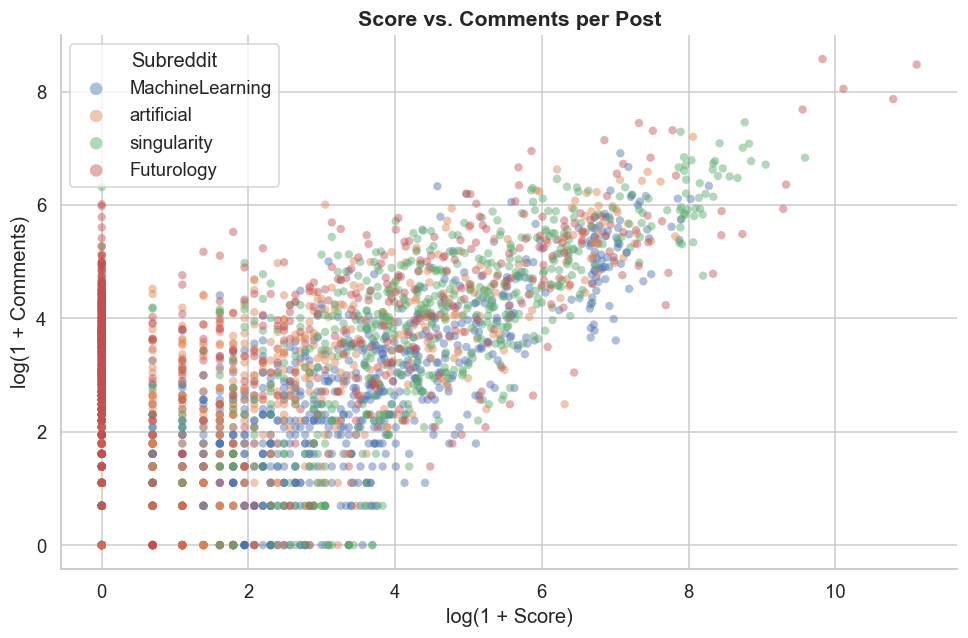

In [29]:
# Plot 9 - score vs comments
fig, ax = plt.subplots(figsize=(9, 6))

for sub in SUB_ORDER:
    subset = df[df["subreddit"] == sub]
    ax.scatter(
        np.log1p(subset["score"]),
        np.log1p(subset["num_comments"]),
        label=sub,
        color=PALETTE[sub],
        alpha=0.45,
        s=30,
        edgecolors="none"
    )

ax.set_title("Score vs. Comments per Post", fontsize=14, fontweight="bold")
ax.set_xlabel("log(1 + Score)")
ax.set_ylabel("log(1 + Comments)")
ax.legend(title="Subreddit", markerscale=1.5)
sns.despine()
plt.tight_layout()
plt.show()

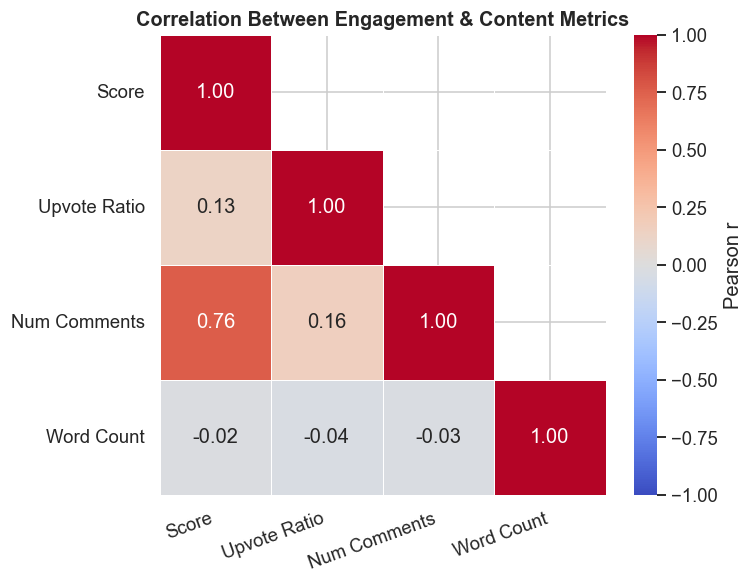

In [30]:
# Plot 10 - Correlation heatmap (score, upvote_ratio, num_comments, text_word_count)
corr_cols = ["score", "upvote_ratio", "num_comments", "text_word_count"]
corr_labels = ["Score", "Upvote Ratio", "Num Comments", "Word Count"]

corr_matrix = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(7, 5.5))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)  # hide mirror half

sns.heatmap(
    corr_matrix,
    annot=True, fmt=".2f",
    cmap="coolwarm", center=0,
    vmin=-1, vmax=1,
    linewidths=0.5,
    mask=mask,
    ax=ax,
    cbar_kws={"label": "Pearson r"}
)
ax.set_title("Correlation Between Engagement & Content Metrics", fontsize=13, fontweight="bold")
ax.set_xticklabels(corr_labels, rotation=20, ha="right")
ax.set_yticklabels(corr_labels, rotation=0)
plt.tight_layout()
plt.show()

This heatmap gives us a good sense of the correlations. Score and comment count are highly correlated (r = 0.87) which basically means that popular posts get discussed more. Since they carry similar information, a classifier only needs one of them.

## Section 4 — Temporal Analysis

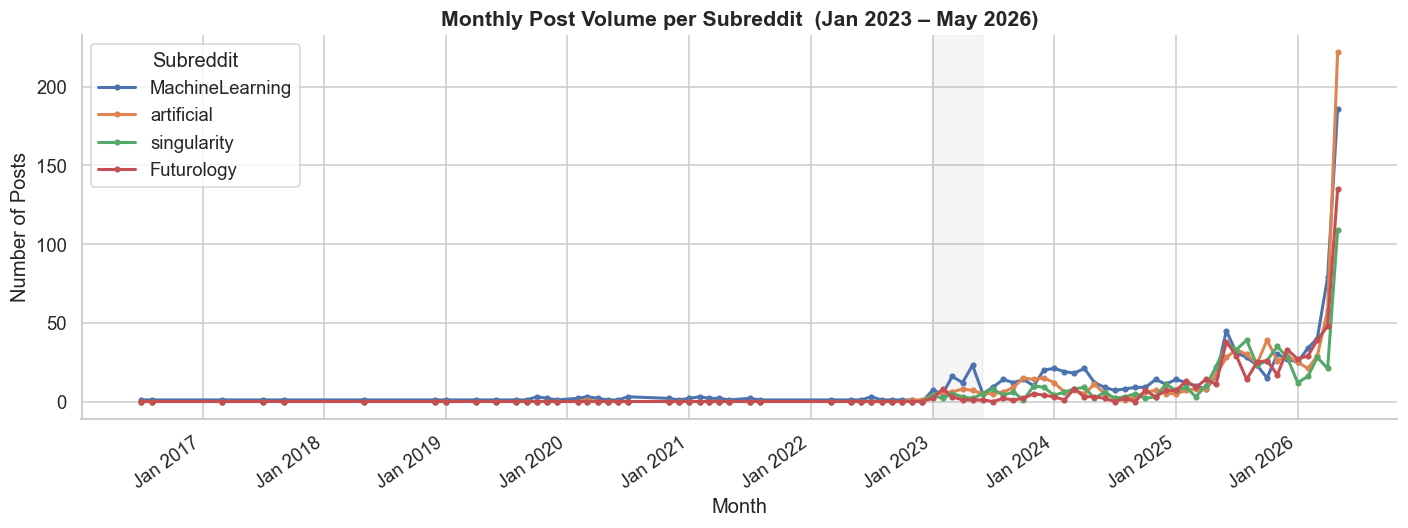

In [31]:
# Plot 11 — Monthly post info per subreddit (Jan 2023 to May 2026)
df["year_month"] = df["created_dt"].dt.to_period("M")

monthly = (
    df.groupby(["year_month", "subreddit"])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=SUB_ORDER)
)
# convert to timestamps
monthly.index = monthly.index.to_timestamp()

fig, ax = plt.subplots(figsize=(13, 5))

for sub in SUB_ORDER:
    ax.plot(
        monthly.index, monthly[sub],
        label=sub, color=PALETTE[sub],
        linewidth=2, marker="o", markersize=3
    )

ax.set_title("Monthly Post Volume per Subreddit  (Jan 2023 – May 2026)", fontsize=14, fontweight="bold")
ax.set_xlabel("Month")
ax.set_ylabel("Number of Posts")
ax.legend(title="Subreddit", loc="upper left")

# Color the ChatGPT launch era as a reference point
import matplotlib.patches as mpatches
ax.axvspan(
    pd.Timestamp("2023-01-01"), pd.Timestamp("2023-06-01"),
    alpha=0.08, color="gray", label="Early 2023 (ChatGPT era)"
)
ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter("%b %Y"))
fig.autofmt_xdate(rotation=35)
sns.despine()
plt.tight_layout()
plt.show()

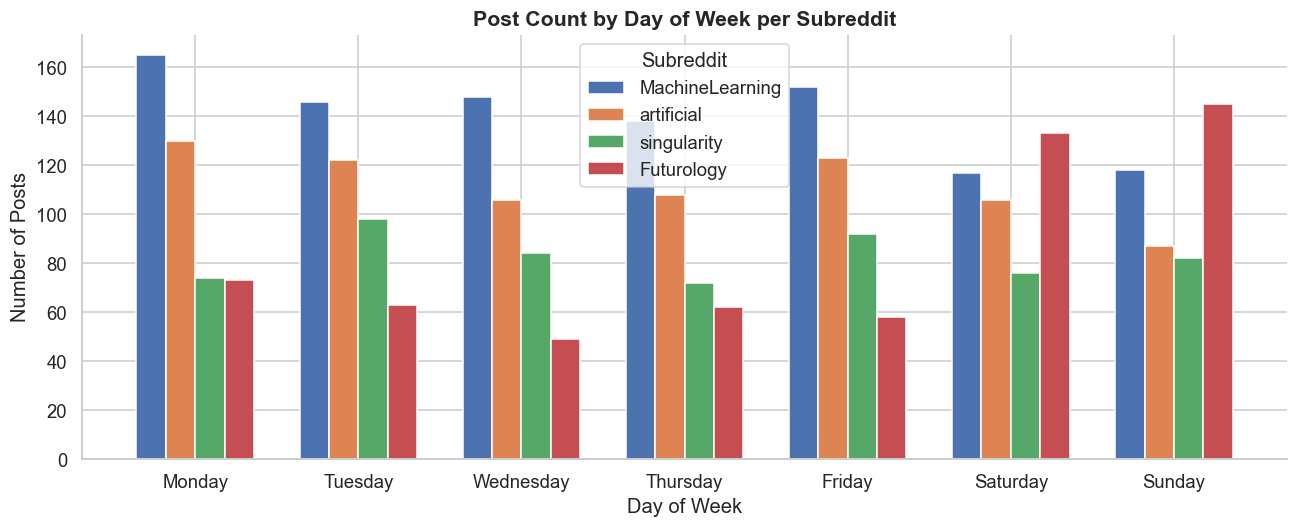

In [32]:
# Plot 12 is post by day of week
day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
df["day_of_week"] = df["created_dt"].dt.day_name()

dow_counts = (
    df.groupby(["day_of_week", "subreddit"])
    .size()
    .unstack(fill_value=0)
    .reindex(day_order)
    .reindex(columns=SUB_ORDER)
)

x = np.arange(len(day_order))
n = len(SUB_ORDER)
bar_width = 0.18
offsets = np.linspace(-(n - 1) / 2, (n - 1) / 2, n) * bar_width

fig, ax = plt.subplots(figsize=(12, 5))

for i, sub in enumerate(SUB_ORDER):
    ax.bar(
        x + offsets[i], dow_counts[sub],
        width=bar_width, label=sub,
        color=PALETTE[sub], edgecolor="white"
    )

ax.set_title("Post Count by Day of Week per Subreddit", fontsize=14, fontweight="bold")
ax.set_xlabel("Day of Week")
ax.set_ylabel("Number of Posts")
ax.set_xticks(x)
ax.set_xticklabels(day_order)
ax.legend(title="Subreddit")
sns.despine()
plt.tight_layout()
plt.show()

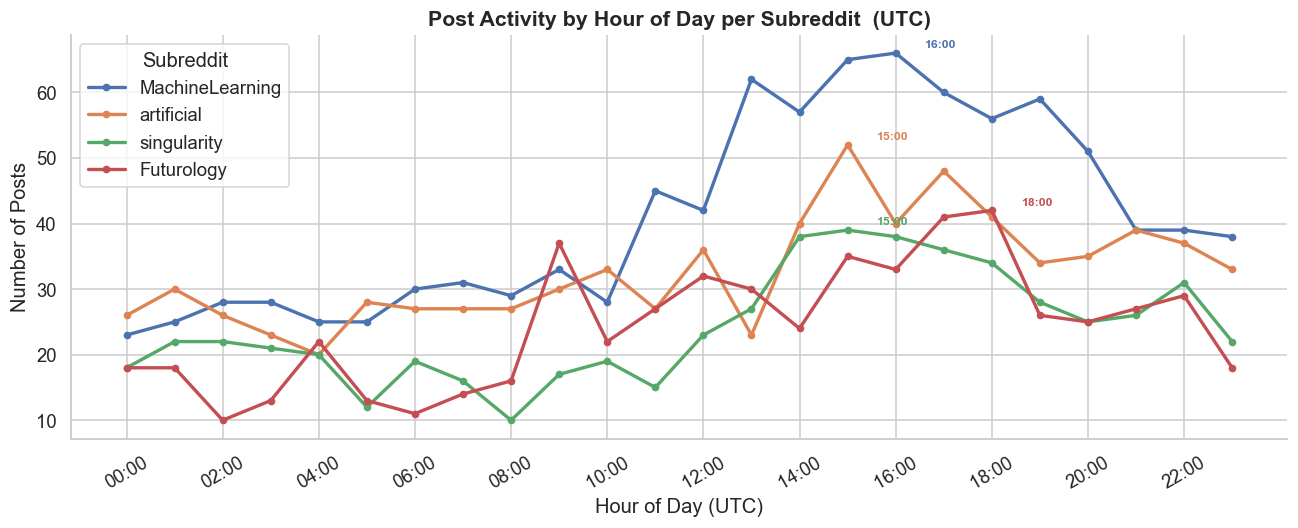

In [33]:
# Plot 13 — hourly activity
df["hour"] = df["created_dt"].dt.hour

hourly = (
    df.groupby(["hour", "subreddit"])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=SUB_ORDER)
)

fig, ax = plt.subplots(figsize=(12, 5))

for sub in SUB_ORDER:
    ax.plot(
        hourly.index, hourly[sub],
        label=sub, color=PALETTE[sub],
        linewidth=2.2, marker="o", markersize=4
    )

# mark peak hour
for sub in SUB_ORDER:
    peak_hour = hourly[sub].idxmax()
    peak_val  = hourly[sub].max()
    ax.annotate(
        f"{peak_hour}:00",
        xy=(peak_hour, peak_val),
        xytext=(peak_hour + 0.6, peak_val + 0.8),
        fontsize=8, color=PALETTE[sub], fontweight="bold"
    )

ax.set_title("Post Activity by Hour of Day per Subreddit  (UTC)", fontsize=14, fontweight="bold")
ax.set_xlabel("Hour of Day (UTC)")
ax.set_ylabel("Number of Posts")
ax.set_xticks(range(0, 24, 2))
ax.set_xticklabels([f"{h:02d}:00" for h in range(0, 24, 2)], rotation=30)
ax.legend(title="Subreddit")
sns.despine()
plt.tight_layout()
plt.show()

All four subreddits peak around 14:00–16:00 UTC (10am–12pm US Eastern). The dominant audience is North American, posting during working hours.

## Section 5 — Vocabulary & Text Analysis

In [34]:
# adding extra reddit-specific stopwords for better tokenization
EXTRA_STOPS = {
    "like", "one", "would", "think", "people", "really", "know", "also",
    "get", "even", "much", "make", "way", "im", "dont", "ve", "use",
    "used", "using", "can", "just", "see", "many", "new", "want", "need",
    "will", "may", "still", "well", "good", "time", "made", "say", "said",
    "thing", "lot", "going", "go", "got", "back", "actually", "right",
    "something", "anything", "everything", "us", "could", "never", "always",
}
stop_words_extended = set(stopwords.words("english")) | EXTRA_STOPS

def tokenize_for_vocab(text):
    text = str(text).lower()
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"[^a-z\s]", "", text)
    tokens = text.split()
    return [t for t in tokens if t not in stop_words_extended and len(t) > 2]

# Build token lists once
sub_tokens = {sub: [] for sub in SUB_ORDER}
for _, row in df.iterrows():
    tokens = tokenize_for_vocab(row["text"])
    sub_tokens[row["subreddit"]].extend(tokens)

print("Token counts per subreddit:")
for sub in SUB_ORDER:
    print(f"  {sub:20s}: {len(sub_tokens[sub]):,} tokens  |  {len(set(sub_tokens[sub])):,} unique")

Token counts per subreddit:
  MachineLearning     : 139,091 tokens  |  17,561 unique
  artificial          : 134,916 tokens  |  17,433 unique
  singularity         : 93,530 tokens  |  13,818 unique
  Futurology          : 98,193 tokens  |  15,618 unique


We are performing one significant step here. We extend NLTK's stopword list with Reddit-specific noise ("like", "just", "actually") that appear heavily in all four subreddits but don't help differentiate between them. Token lists are built once here and reused across all vocabulary plots below.

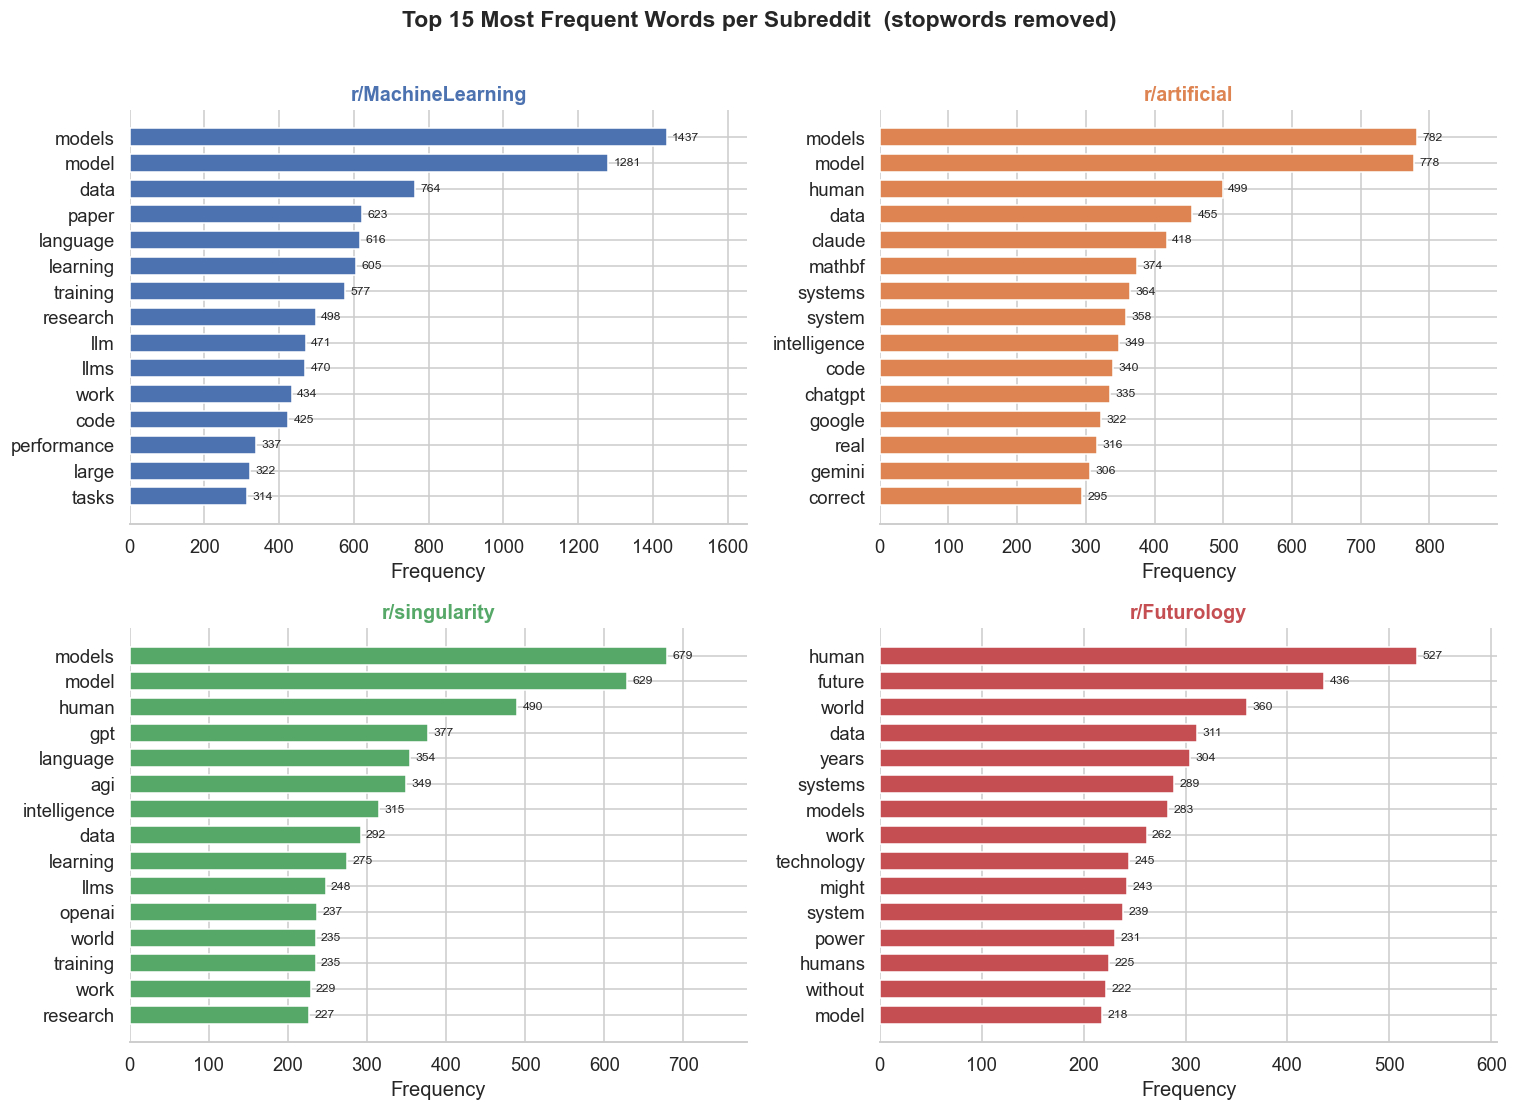

In [35]:
# Plot 14 — top words
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, sub in enumerate(SUB_ORDER):
    top15  = Counter(sub_tokens[sub]).most_common(15)
    words  = [w for w, _ in reversed(top15)]
    counts = [c for _, c in reversed(top15)]

    ax = axes[i]
    bars = ax.barh(words, counts, color=PALETTE[sub], edgecolor="white", height=0.7)

    for bar, val in zip(bars, counts):
        ax.text(bar.get_width() + max(counts) * 0.01, bar.get_y() + bar.get_height() / 2,
                str(val), va="center", fontsize=8)

    ax.set_title(f"r/{sub}", fontsize=13, fontweight="bold", color=PALETTE[sub])
    ax.set_xlabel("Frequency")
    ax.set_xlim(0, max(counts) * 1.15)
    sns.despine(ax=ax, left=True)

fig.suptitle("Top 15 Most Frequent Words per Subreddit  (stopwords removed)",
             fontsize=15, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

MachineLearning: academic terms (model, training, paper, llm). Futurology: philosophical (human, future, world). artificial: product-focused (claude, chatgpt). singularity: agi, gpt. Shared words like "model" appear everywhere, but the main differences are in emphasis, not vocabulary.

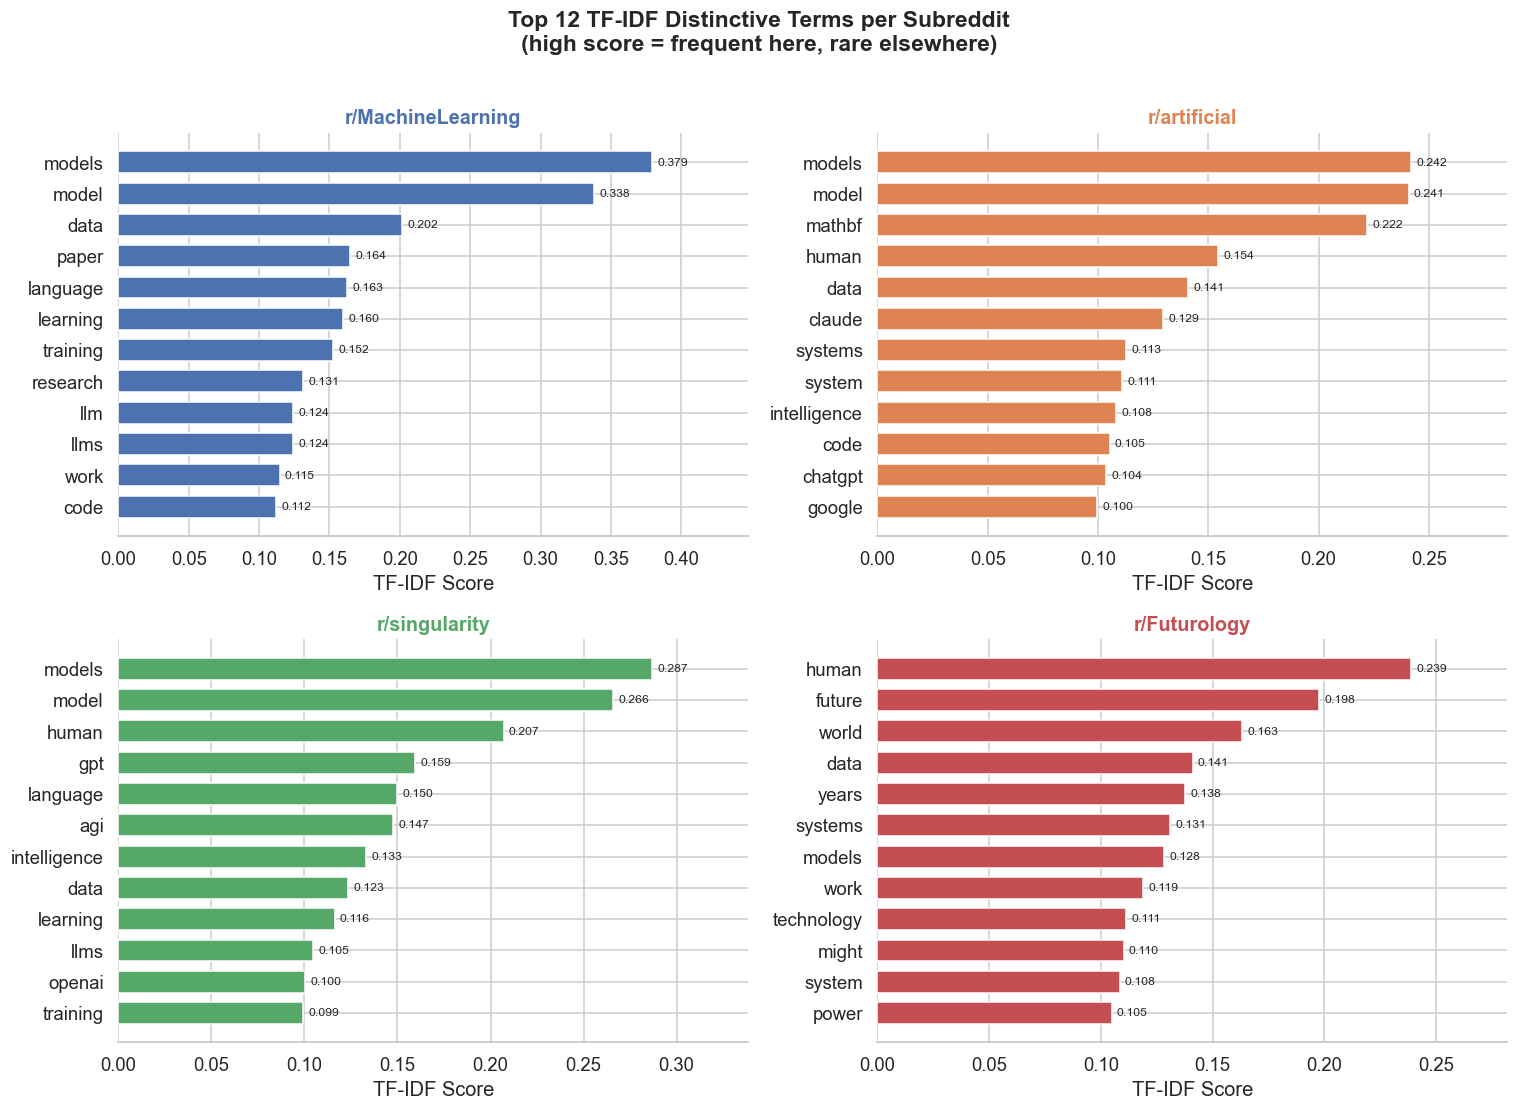

In [36]:

sub_docs = {
    sub: " ".join(tokenize_for_vocab(" ".join(df[df["subreddit"] == sub]["text"])))
    for sub in SUB_ORDER
}

tfidf    = TfidfVectorizer(max_features=5000, ngram_range=(1, 1))
tfidf_matrix  = tfidf.fit_transform(list(sub_docs.values()))
feature_names = tfidf.get_feature_names_out()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, sub in enumerate(SUB_ORDER):
    scores   = tfidf_matrix[i].toarray().flatten()
    top_idx  = scores.argsort()[-12:]
    top_words  = [feature_names[j] for j in top_idx]
    top_scores = [scores[j]        for j in top_idx]

    ax = axes[i]
    bars = ax.barh(top_words, top_scores, color=PALETTE[sub], edgecolor="white", height=0.7)

    for bar, val in zip(bars, top_scores):
        ax.text(bar.get_width() + max(top_scores) * 0.01, bar.get_y() + bar.get_height() / 2,
                f"{val:.3f}", va="center", fontsize=8)

    ax.set_title(f"r/{sub}", fontsize=13, fontweight="bold", color=PALETTE[sub])
    ax.set_xlabel("TF-IDF Score")
    ax.set_xlim(0, max(top_scores) * 1.18)
    sns.despine(ax=ax, left=True)

fig.suptitle("Top 12 TF-IDF Distinctive Terms per Subreddit\n(high score = frequent here, rare elsewhere)",
             fontsize=15, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

Unlike raw frequency, TF-IDF scores are high for words that are common in one subreddit but rare in the others. These are the discriminative features the classifier will rely on most.

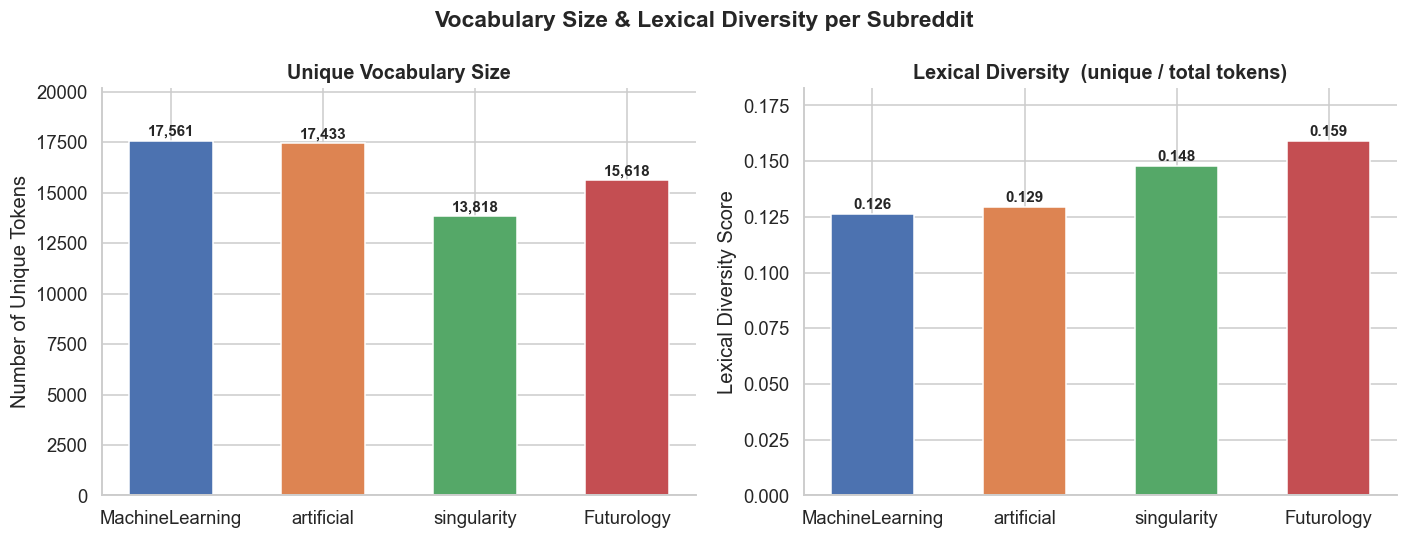

In [37]:
# Plot 16 — vocab stats
vocab_stats = {}
for sub in SUB_ORDER:
    tokens    = sub_tokens[sub]
    total     = len(tokens)
    unique    = len(set(tokens))
    diversity = unique / total if total > 0 else 0
    vocab_stats[sub] = {"unique_tokens": unique, "lexical_diversity": diversity}

vocab_df = pd.DataFrame(vocab_stats).T.reindex(SUB_ORDER)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# Left: unique words
bars1 = ax1.bar(SUB_ORDER, vocab_df["unique_tokens"],
                color=[PALETTE[s] for s in SUB_ORDER], edgecolor="white", width=0.55)
for bar, val in zip(bars1, vocab_df["unique_tokens"]):
    ax1.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 100,
             f"{int(val):,}", ha="center", va="bottom", fontsize=10, fontweight="bold")
ax1.set_title("Unique Vocabulary Size", fontsize=13, fontweight="bold")
ax1.set_ylabel("Number of Unique Tokens")
ax1.set_ylim(0, max(vocab_df["unique_tokens"]) * 1.15)
sns.despine(ax=ax1)

# Right: lexical diversity
bars2 = ax2.bar(SUB_ORDER, vocab_df["lexical_diversity"],
                color=[PALETTE[s] for s in SUB_ORDER], edgecolor="white", width=0.55)
for bar, val in zip(bars2, vocab_df["lexical_diversity"]):
    ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.001,
             f"{val:.3f}", ha="center", va="bottom", fontsize=10, fontweight="bold")
ax2.set_title("Lexical Diversity  (unique / total tokens)", fontsize=13, fontweight="bold")
ax2.set_ylabel("Lexical Diversity Score")
ax2.set_ylim(0, max(vocab_df["lexical_diversity"]) * 1.15)
sns.despine(ax=ax2)

fig.suptitle("Vocabulary Size & Lexical Diversity per Subreddit", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()

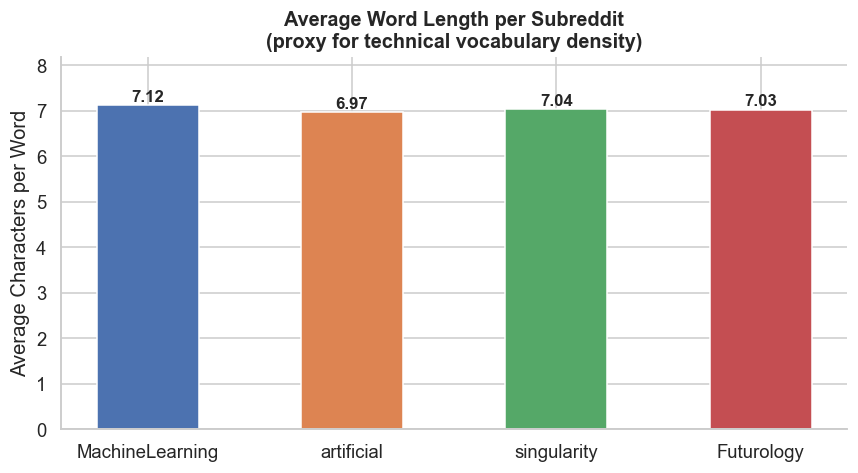

In [38]:
# Plot 17 — avg word length
avg_word_len = {
    sub: np.mean([len(t) for t in sub_tokens[sub]]) if sub_tokens[sub] else 0
    for sub in SUB_ORDER
}

fig, ax = plt.subplots(figsize=(8, 4.5))
bars = ax.bar(SUB_ORDER, [avg_word_len[s] for s in SUB_ORDER],
              color=[PALETTE[s] for s in SUB_ORDER], edgecolor="white", width=0.5)

for bar, sub in zip(bars, SUB_ORDER):
    val = avg_word_len[sub]
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.02,
            f"{val:.2f}", ha="center", va="bottom", fontsize=11, fontweight="bold")

ax.set_title("Average Word Length per Subreddit\n(proxy for technical vocabulary density)",
             fontsize=13, fontweight="bold")
ax.set_ylabel("Average Characters per Word")
ax.set_ylim(0, max(avg_word_len.values()) * 1.15)
sns.despine()
plt.tight_layout()
plt.show()

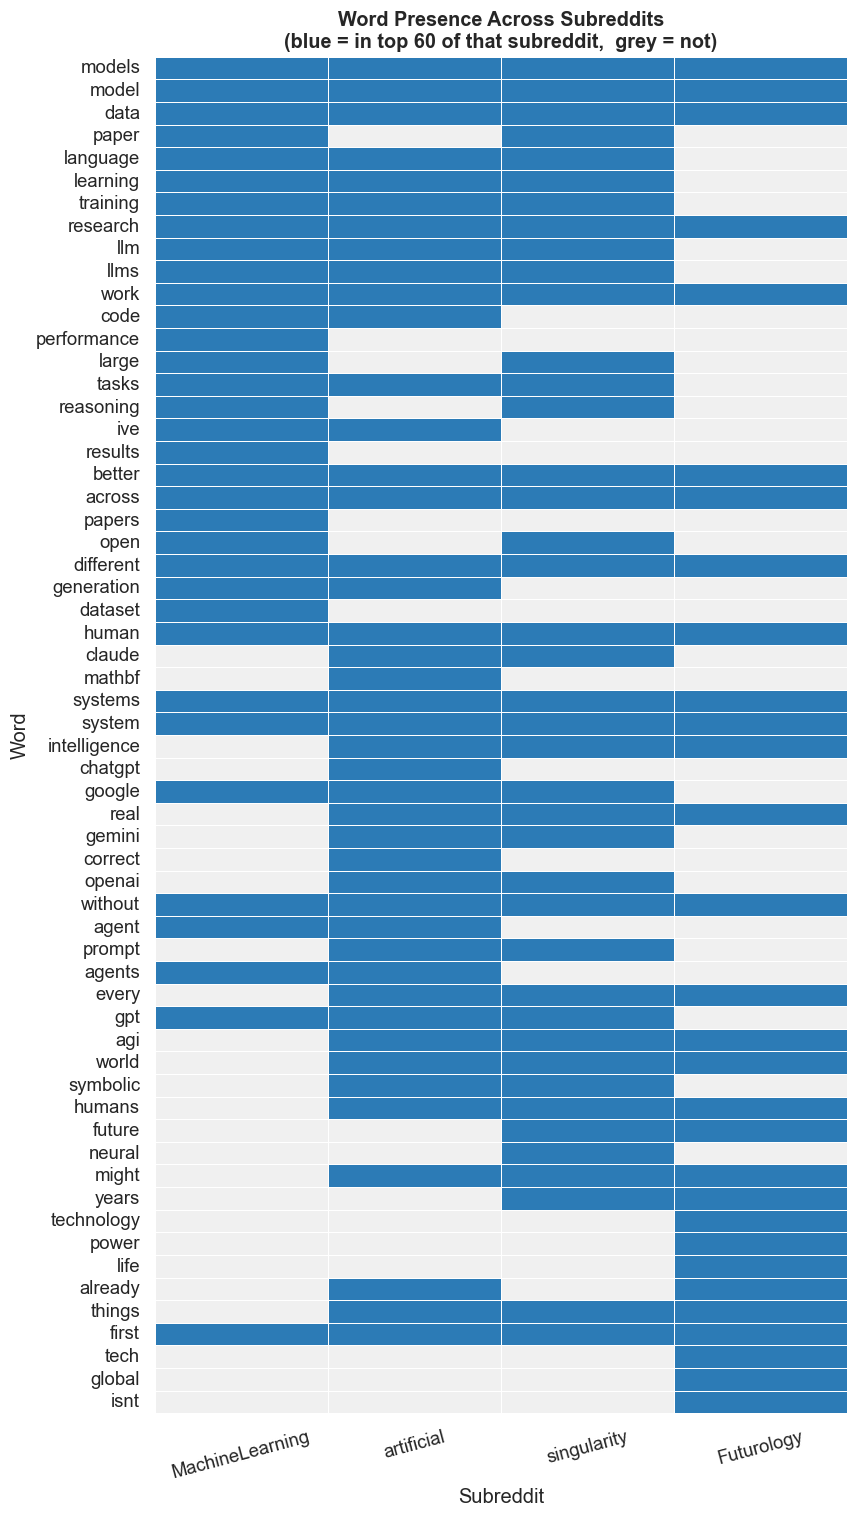

In [39]:
# Plot 18 — word presence heatmap
N_TOP   = 25   
N_CHECK = 60   

# Union of each subreddit’s top 25
candidate_words = []
for sub in SUB_ORDER:
    for w, _ in Counter(sub_tokens[sub]).most_common(N_TOP):
        if w not in candidate_words:
            candidate_words.append(w)

# Top-60 words per subreddit
sub_top60 = {
    sub: set(w for w, _ in Counter(sub_tokens[sub]).most_common(N_CHECK))
    for sub in SUB_ORDER
}

# Presence matrix
presence = pd.DataFrame(
    {sub: [1 if w in sub_top60[sub] else 0 for w in candidate_words] for sub in SUB_ORDER},
    index=candidate_words
)

fig, ax = plt.subplots(figsize=(8, 14))
sns.heatmap(
    presence,
    cmap=["#f0f0f0", "#2c7bb6"],
    linewidths=0.4, linecolor="white",
    cbar=False, ax=ax,
    xticklabels=SUB_ORDER,
    yticklabels=candidate_words
)
ax.set_title(
    "Word Presence Across Subreddits\n(blue = in top 60 of that subreddit,  grey = not)",
    fontsize=13, fontweight="bold"
 )
ax.set_xlabel("Subreddit")
ax.set_ylabel("Word")
ax.set_xticklabels(SUB_ORDER, rotation=15)
plt.tight_layout()
plt.show()

In this graph here, Blue = word is in a subreddit's top 60 whereas grey = not. Single-column blue rows are the most useful features for classification. All-blue rows are shared vocabulary with low classifier value.

---

# Section 3 — TF-IDF Feature Extraction

---

In [40]:
import os
import re
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.sparse
import nltk
from pathlib import Path
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split

nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)

# Project root — works regardless of where the kernel is launched from
notebook_dir = Path().resolve()
project_root = notebook_dir.parent if notebook_dir.name == 'notebooks' else notebook_dir
os.chdir(project_root)
print('Working directory:', os.getcwd())

# Consistent palette and order — matches notebook 02
PALETTE = {
    'MachineLearning': '#4C72B0',
    'artificial':      '#DD8452',
    'singularity':     '#55A868',
    'Futurology':      '#C44E52',
}
SUB_ORDER    = ['MachineLearning', 'artificial', 'singularity', 'Futurology']
RANDOM_STATE = 42

sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams['figure.dpi'] = 110

Working directory: /Users/varunsardana/PSTAT-134-Final-Project


In [41]:
df = pd.read_csv('data/reddit_ai_posts_CLEAN.csv')

print(f'Loaded {len(df)} posts across {df["subreddit"].nunique()} subreddits')
print()
print('Class distribution:')
counts = df['subreddit'].value_counts().reindex(SUB_ORDER)
for sub, n in counts.items():
    pct = n / len(df) * 100
    print(f'  {sub:20s}: {n:4d} posts  ({pct:.1f}%)')
print()
print('Columns:', df.columns.tolist())

Loaded 2927 posts across 4 subreddits

Class distribution:
  MachineLearning     :  984 posts  (33.6%)
  artificial          :  782 posts  (26.7%)
  singularity         :  578 posts  (19.7%)
  Futurology          :  583 posts  (19.9%)

Columns: ['id', 'subreddit', 'title', 'selftext', 'text', 'text_word_count', 'has_body', 'upvote_ratio', 'num_comments', 'score', 'is_self', 'edited', 'created_utc', 'created_dt', 'url', 'permalink']


In [42]:
# Base NLTK stopwords
stop_words = set(stopwords.words('english'))

# Extended stopwords, Reddit-specific noise words that appear heavily in all
EXTRA_STOPS = {
    "like", "one", "would", "think", "people", "really", "know", "also",
    "get", "even", "much", "make", "way", "im", "dont", "ve", "use",
    "used", "using", "can", "just", "see", "many", "new", "want", "need",
    "will", "may", "still", "well", "good", "time", "made", "say", "said",
    "thing", "lot", "going", "go", "got", "back", "actually", "right",
    "something", "anything", "everything", "us", "could", "never", "always",
}

stop_words = stop_words | EXTRA_STOPS
lemmatizer = WordNetLemmatizer()

def preprocess(text):
    text = str(text).lower()
    text = re.sub(r'http\S+', '', text)          # remove URLs
    text = re.sub(r'[^a-z\s]', '', text)         # keep only letters
    text = re.sub(r'\s+', ' ', text).strip()     # collapse whitespace
    tokens = text.split()
    tokens = [t for t in tokens if t not in stop_words]   # stopwords + EXTRA_STOPS
    tokens = [lemmatizer.lemmatize(t) for t in tokens]    # lemmatize
    return ' '.join(tokens)

print(f'Base NLTK stopwords : {len(set(stopwords.words("english")))}')
print(f'EXTRA_STOPS added   : {len(EXTRA_STOPS)}')
print(f'Total stop_words    : {len(stop_words)}')
print()
print('Applying preprocessing to all 1,395 posts...')
df['text_processed'] = df['text'].apply(preprocess)
print('Done.')
print()
print('Sample — raw text:')
print(' ', df['text'].iloc[0][:180])
print()
print('Sample — after preprocessing:')
print(' ', df['text_processed'].iloc[0][:180])

Base NLTK stopwords : 198
EXTRA_STOPS added   : 50
Total stop_words    : 244

Applying preprocessing to all 1,395 posts...
Done.

Sample — raw text:
  Pulling together different technologies to make interstellar colonization possible Here are some fascinating articles and links about seemingly unrelated technologies: 1. [Babies b

Sample — after preprocessing:
  pulling together different technology interstellar colonization possible fascinating article link seemingly unrelated technology baby born year frozen embryo seed thousand year old


## Train / Test Split

80/20 stratified split. The same `random_state=42` is used throughout and all sections are evaluated on the same held-out test set.

In [43]:
X = df['text_processed']
y = df['subreddit']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=RANDOM_STATE
)

print(f'Train set : {len(X_train):4d} posts  ({len(X_train)/len(df)*100:.0f}%)')
print(f'Test set  : {len(X_test):4d} posts  ({len(X_test)/len(df)*100:.0f}%)')
print()
print('Class distribution in train set:')
train_counts = y_train.value_counts().reindex(SUB_ORDER)
for sub, n in train_counts.items():
    print(f'  {sub:20s}: {n}')
print()
print('Class distribution in test set:')
test_counts = y_test.value_counts().reindex(SUB_ORDER)
for sub, n in test_counts.items():
    print(f'  {sub:20s}: {n}')

Train set : 2341 posts  (80%)
Test set  :  586 posts  (20%)

Class distribution in train set:
  MachineLearning     : 787
  artificial          : 626
  singularity         : 462
  Futurology          : 466

Class distribution in test set:
  MachineLearning     : 197
  artificial          : 156
  singularity         : 116
  Futurology          : 117


In [44]:
vectorizer = TfidfVectorizer(
    max_features  = 15000,
    min_df        = 3,
    max_df        = 0.90,
    ngram_range   = (1, 2),
    sublinear_tf  = True,
    strip_accents = 'unicode',
)

# Fit on train only — transform both
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf  = vectorizer.transform(X_test)

feature_names = vectorizer.get_feature_names_out()

print(f'Vocabulary size (after min_df / max_df filtering): {len(feature_names):,}')
print(f'Train matrix shape : {X_train_tfidf.shape}  (posts x features)')
print(f'Test  matrix shape : {X_test_tfidf.shape}')

Vocabulary size (after min_df / max_df filtering): 15,000
Train matrix shape : (2341, 15000)  (posts x features)
Test  matrix shape : (586, 15000)


In [45]:

total_elements = X_train_tfidf.shape[0] * X_train_tfidf.shape[1]
nonzero        = X_train_tfidf.nnz
sparsity       = 1 - (nonzero / total_elements)
density        = nonzero / total_elements

# Memory footprint of sparse vs dense
sparse_mb = (X_train_tfidf.data.nbytes + X_train_tfidf.indices.nbytes + X_train_tfidf.indptr.nbytes) / 1e6
dense_mb  = (total_elements * 8) / 1e6   # 8 bytes per float64

print(' Train Matrix Statistics')
print(f'  Shape          : {X_train_tfidf.shape[0]} posts  x  {X_train_tfidf.shape[1]:,} features')
print(f'  Non-zero values: {nonzero:,}')
print(f'  Sparsity       : {sparsity*100:.2f}%  (most entries are 0 — expected for TF-IDF)')
print(f'  Density        : {density*100:.2f}%')
print(f'  Memory — sparse: {sparse_mb:.1f} MB')
print(f'  Memory — dense : {dense_mb:.0f} MB  (what it would cost without sparse storage)')
print()

# Per-post feature stats
features_per_post = np.diff(X_train_tfidf.indptr)   # non-zero features per row
print('Features (non-zero) per post:')
print(f'  Mean   : {features_per_post.mean():.1f}')
print(f'  Median : {np.median(features_per_post):.0f}')
print(f'  Min    : {features_per_post.min()}')
print(f'  Max    : {features_per_post.max()}')

 Train Matrix Statistics
  Shape          : 2341 posts  x  15,000 features
  Non-zero values: 268,991
  Sparsity       : 99.23%  (most entries are 0 — expected for TF-IDF)
  Density        : 0.77%
  Memory — sparse: 3.2 MB
  Memory — dense : 281 MB  (what it would cost without sparse storage)

Features (non-zero) per post:
  Mean   : 114.9
  Median : 81
  Min    : 5
  Max    : 1488


Each post activates around 115 features on average (median 81 out of 15,000). 99.23% sparsity means scipy's sparse format stores this in 3.2 MB instead of 281 MB dense.

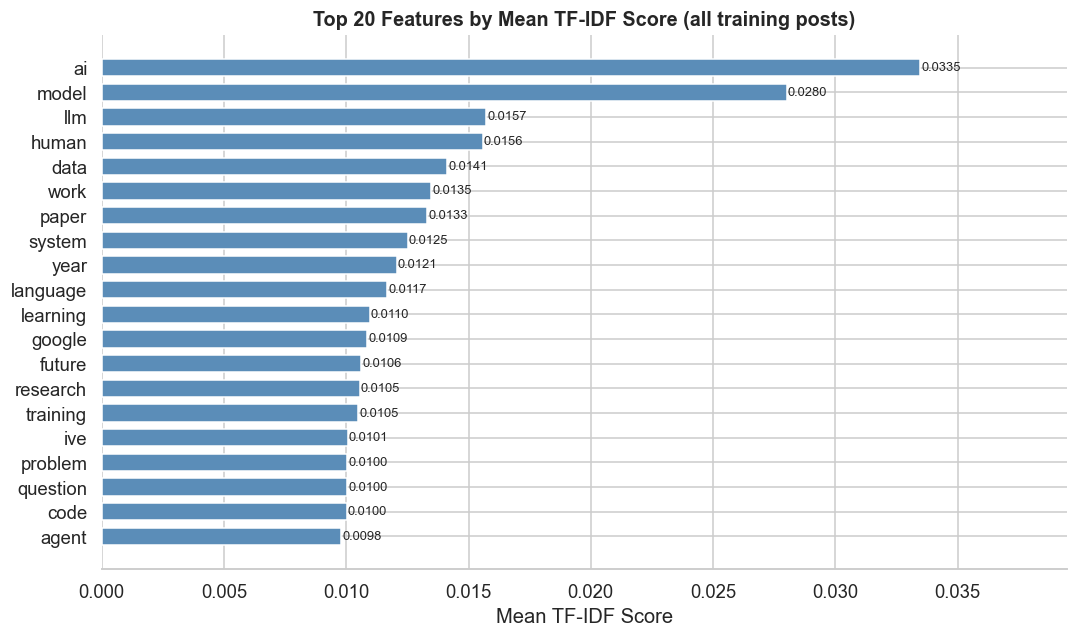

Unigrams in top 20: ['ai', 'model', 'llm', 'human', 'data', 'work', 'paper', 'system', 'year', 'language', 'learning', 'google', 'future', 'research', 'training', 'ive', 'problem', 'question', 'code', 'agent']
Bigrams  in top 20: []


In [46]:
# Mean TF-IDF score per feature across all training docs
mean_tfidf = np.asarray(X_train_tfidf.mean(axis=0)).flatten()
top20_idx  = mean_tfidf.argsort()[-20:][::-1]
top20_words  = [feature_names[i] for i in top20_idx]
top20_scores = [mean_tfidf[i] for i in top20_idx]

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(top20_words[::-1], top20_scores[::-1], color='#5B8DB8', edgecolor='white', height=0.7)

for bar, val in zip(bars, top20_scores[::-1]):
    ax.text(bar.get_width() + 0.00005, bar.get_y() + bar.get_height() / 2,
            f'{val:.4f}', va='center', fontsize=8.5)

ax.set_title('Top 20 Features by Mean TF-IDF Score (all training posts)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Mean TF-IDF Score')
ax.set_xlim(0, max(top20_scores) * 1.18)
sns.despine(ax=ax, left=True)
plt.tight_layout()
plt.show()

# Separate unigrams from bigrams in the top 20
unigrams = [w for w in top20_words if ' ' not in w]
bigrams  = [w for w in top20_words if ' ' in w]
print(f'Unigrams in top 20: {unigrams}')
print(f'Bigrams  in top 20: {bigrams}')

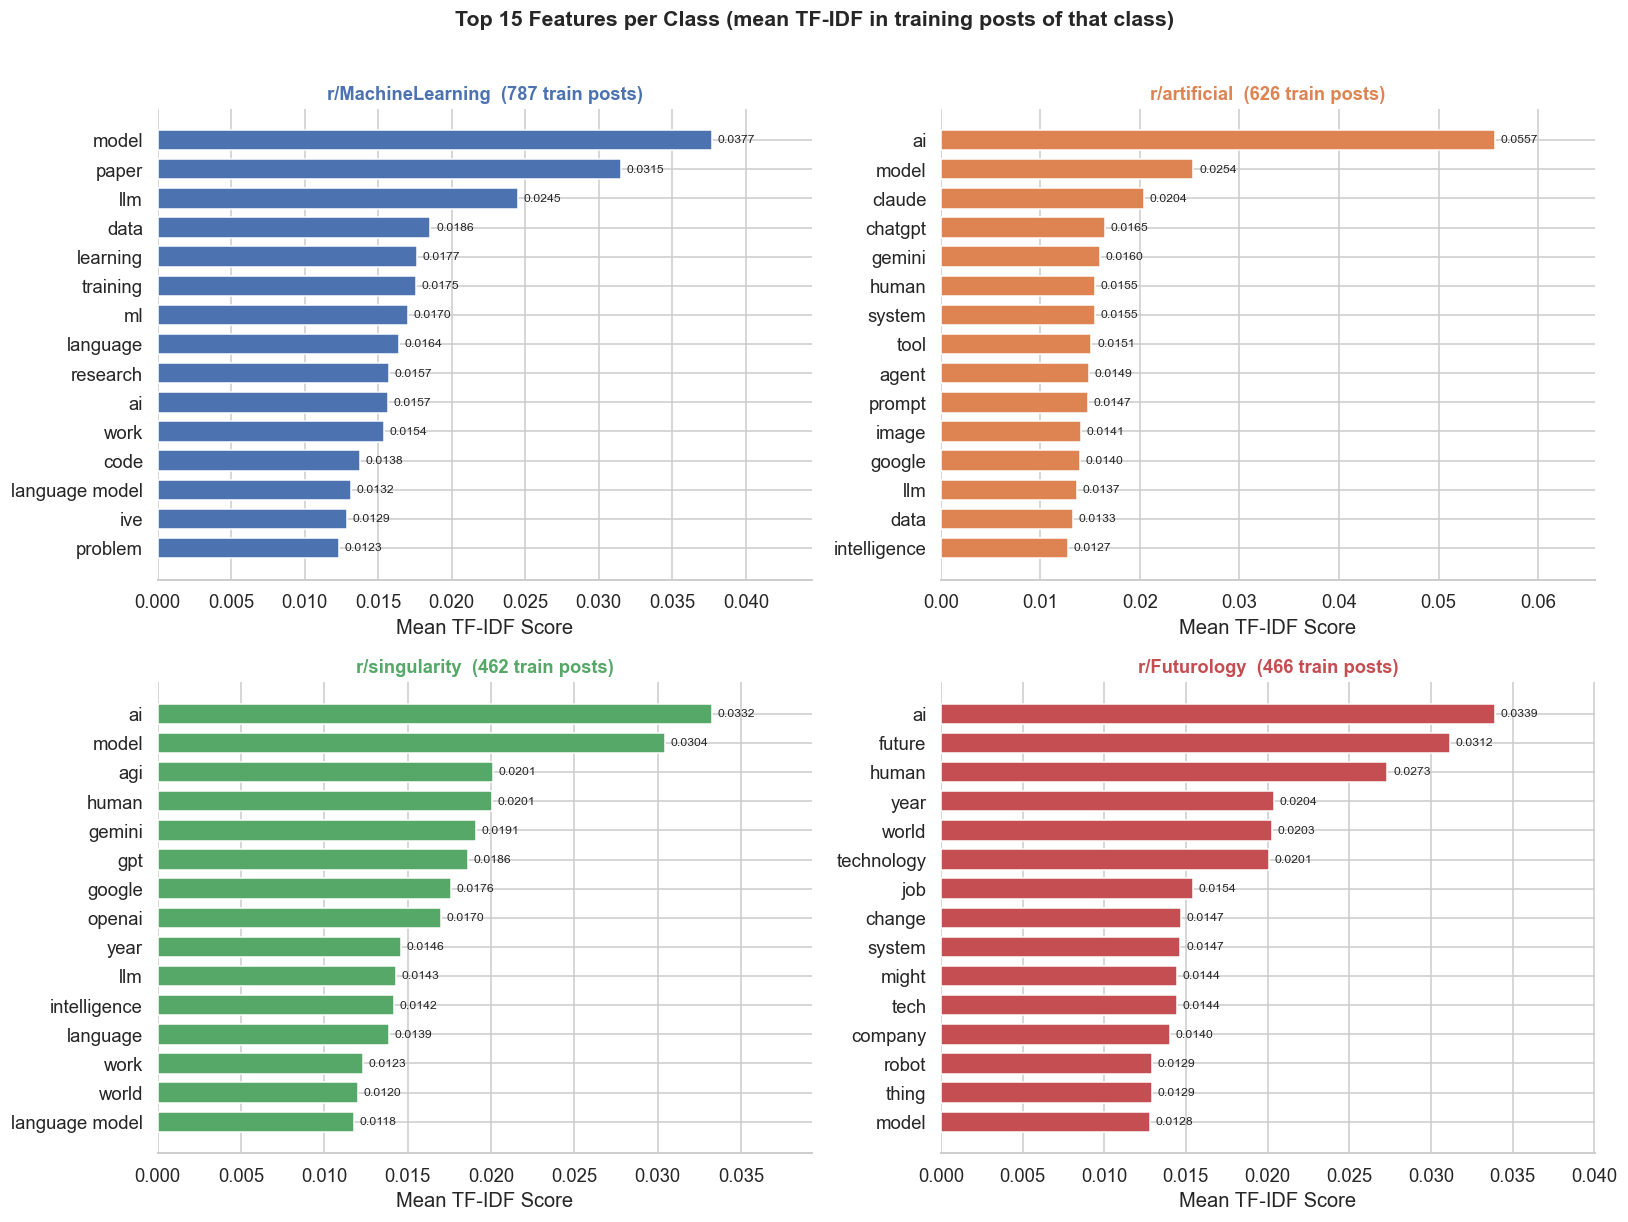

In [47]:
fig, axes = plt.subplots(2, 2, figsize=(15, 11))
axes = axes.flatten()

y_train_arr = np.array(y_train)

per_class_top = {}

for i, sub in enumerate(SUB_ORDER):
    # Rows in training set belonging to this subreddit
    mask        = y_train_arr == sub
    class_matrix = X_train_tfidf[mask]
    
    # Mean TF-IDF per feature for this class
    mean_scores  = np.asarray(class_matrix.mean(axis=0)).flatten()
    top15_idx    = mean_scores.argsort()[-15:]  # ascending, so last 15 = highest
    top15_words  = [feature_names[j] for j in top15_idx]
    top15_scores = [mean_scores[j]   for j in top15_idx]
    
    per_class_top[sub] = list(zip(top15_words, top15_scores))
    
    ax = axes[i]
    bars = ax.barh(top15_words, top15_scores, color=PALETTE[sub], edgecolor='white', height=0.7)
    
    for bar, val in zip(bars, top15_scores):
        ax.text(bar.get_width() + max(top15_scores) * 0.01,
                bar.get_y() + bar.get_height() / 2,
                f'{val:.4f}', va='center', fontsize=8)
    
    n_class = mask.sum()
    ax.set_title(f'r/{sub}  ({n_class} train posts)', fontsize=12, fontweight='bold', color=PALETTE[sub])
    ax.set_xlabel('Mean TF-IDF Score')
    ax.set_xlim(0, max(top15_scores) * 1.18)
    sns.despine(ax=ax, left=True)

fig.suptitle('Top 15 Features per Class (mean TF-IDF in training posts of that class)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## Bigram Analysis

A phrase like "Language model" carries different meaning than the words separately. Top bigrams per class show which two-word phrases best differentiate each community.

Total features     : 15,000
Unigram features   : 8,660
Bigram features    : 6,340



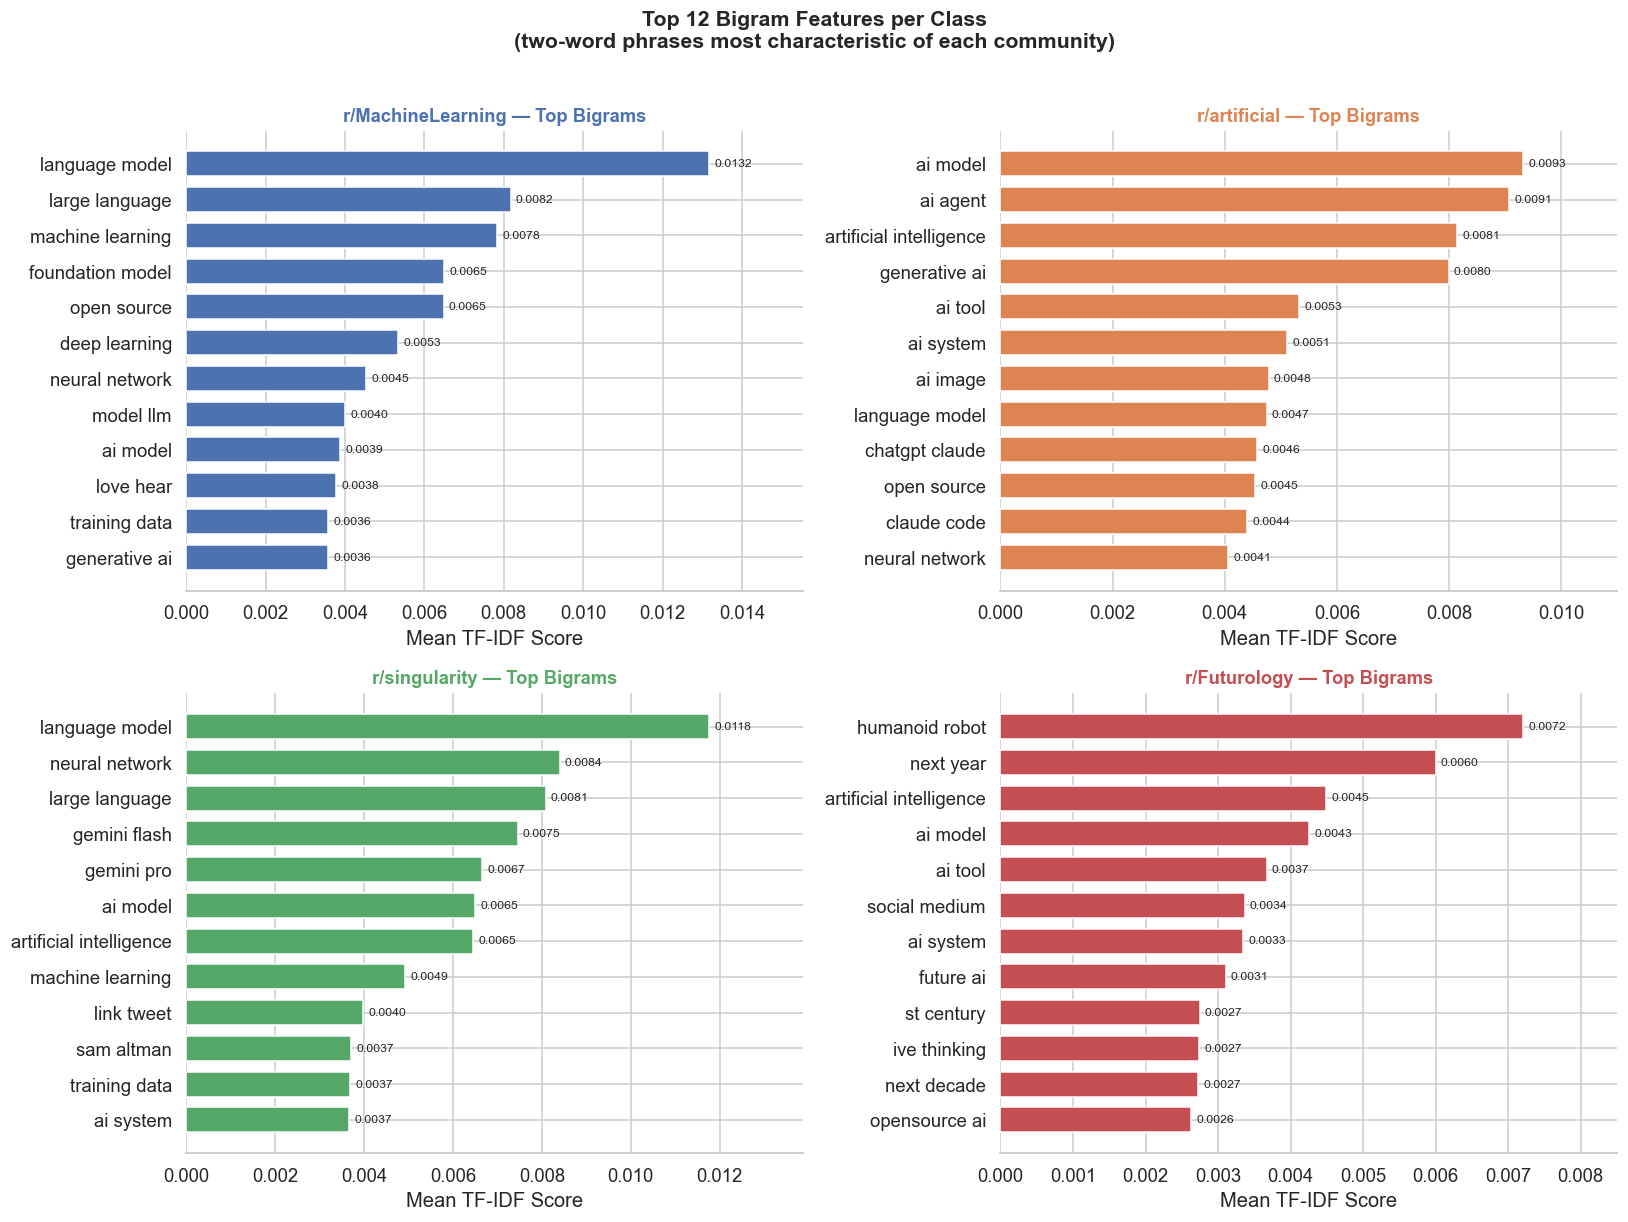

In [48]:
# Bigram indices- any feature name that contains a space
bigram_idx = np.array([i for i, f in enumerate(feature_names) if ' ' in f])
print(f'Total features     : {len(feature_names):,}')
print(f'Unigram features   : {len(feature_names) - len(bigram_idx):,}')
print(f'Bigram features    : {len(bigram_idx):,}')
print()

fig, axes = plt.subplots(2, 2, figsize=(15, 11))
axes = axes.flatten()

y_train_arr = np.array(y_train)

for i, sub in enumerate(SUB_ORDER):
    mask         = y_train_arr == sub
    class_matrix = X_train_tfidf[mask]
    mean_scores  = np.asarray(class_matrix.mean(axis=0)).flatten()
    
    # Restrict to bigrams only
    bigram_scores = mean_scores[bigram_idx]
    top12_local   = bigram_scores.argsort()[-12:]
    top12_words   = [feature_names[bigram_idx[j]] for j in top12_local]
    top12_scores  = [bigram_scores[j]             for j in top12_local]
    
    ax = axes[i]
    bars = ax.barh(top12_words, top12_scores, color=PALETTE[sub], edgecolor='white', height=0.7)
    
    for bar, val in zip(bars, top12_scores):
        ax.text(bar.get_width() + max(top12_scores) * 0.01,
                bar.get_y() + bar.get_height() / 2,
                f'{val:.4f}', va='center', fontsize=8)
    
    ax.set_title(f'r/{sub} — Top Bigrams', fontsize=12, fontweight='bold', color=PALETTE[sub])
    ax.set_xlabel('Mean TF-IDF Score')
    ax.set_xlim(0, max(top12_scores) * 1.18)
    sns.despine(ax=ax, left=True)

fig.suptitle('Top 12 Bigram Features per Class\n(two-word phrases most characteristic of each community)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## Feature Overlap Between Classes

Of the top 100 features per class, how many do pairs of subreddits share? So a higher overlap means harder to separate. This predicts where the classifier will struggle before any training.

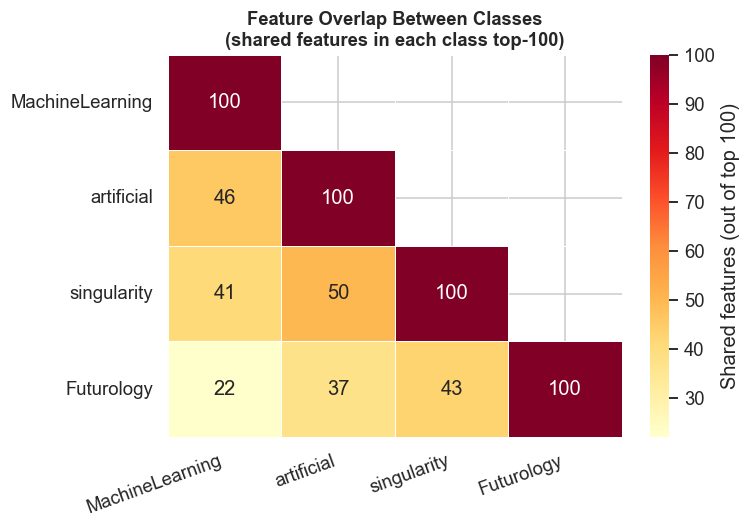


Key insight:
  MachineLearning      vs artificial          :  46 / 100 features shared  (46%)
  MachineLearning      vs singularity         :  41 / 100 features shared  (41%)
  MachineLearning      vs Futurology          :  22 / 100 features shared  (22%)
  artificial           vs singularity         :  50 / 100 features shared  (50%)
  artificial           vs Futurology          :  37 / 100 features shared  (37%)
  singularity          vs Futurology          :  43 / 100 features shared  (43%)


In [49]:
N = 100  # top-N features per class 

y_train_arr   = np.array(y_train)
top_features  = {}

for sub in SUB_ORDER:
    mask         = y_train_arr == sub
    class_matrix = X_train_tfidf[mask]
    mean_scores  = np.asarray(class_matrix.mean(axis=0)).flatten()
    top_idx      = mean_scores.argsort()[-N:]
    top_features[sub] = set(feature_names[top_idx])

# Build pairwise overlap matrix
overlap = pd.DataFrame(index=SUB_ORDER, columns=SUB_ORDER, dtype=int)
for s1 in SUB_ORDER:
    for s2 in SUB_ORDER:
        overlap.loc[s1, s2] = len(top_features[s1] & top_features[s2])

fig, ax = plt.subplots(figsize=(7, 5))
mask_upper = np.triu(np.ones_like(overlap, dtype=bool), k=1)
sns.heatmap(
    overlap.astype(int), annot=True, fmt='d',
    cmap='YlOrRd', linewidths=0.5,
    mask=mask_upper, ax=ax,
    cbar_kws={'label': f'Shared features (out of top {N})'}
)
ax.set_title(f'Feature Overlap Between Classes\n(shared features in each class top-{N})',
             fontsize=12, fontweight='bold')
ax.set_xticklabels(SUB_ORDER, rotation=20, ha='right')
ax.set_yticklabels(SUB_ORDER, rotation=0)
plt.tight_layout()
plt.show()

print('\nKey insight:')
pairs = [(s1, s2) for i, s1 in enumerate(SUB_ORDER) for s2 in SUB_ORDER[i+1:]]
for s1, s2 in pairs:
    shared = len(top_features[s1] & top_features[s2])
    print(f'  {s1:20s} vs {s2:20s}: {shared:3d} / {N} features shared  ({shared}%)')

In [50]:
save_dir = Path('data/tfidf_artifacts')
save_dir.mkdir(parents=True, exist_ok=True)

# Save fitted vectorizer
joblib.dump(vectorizer, save_dir / 'tfidf_vectorizer.joblib')

# Save sparse matrices
scipy.sparse.save_npz(save_dir / 'X_train.npz', X_train_tfidf)
scipy.sparse.save_npz(save_dir / 'X_test.npz',  X_test_tfidf)

# Save labels
np.save(save_dir / 'y_train.npy', np.array(y_train))
np.save(save_dir / 'y_test.npy',  np.array(y_test))

print('Saved to data/tfidf_artifacts/')
for f in sorted(save_dir.iterdir()):
    size_kb = f.stat().st_size / 1024
    print(f'  {f.name:35s}  {size_kb:7.1f} KB')

print()
print('Notebook 04 can now load these directly and there is no need to rerun preprocessing.')

Saved to data/tfidf_artifacts/
  X_test.npz                             527.7 KB
  X_train.npz                           2112.0 KB
  tfidf_vectorizer.joblib                584.4 KB
  y_test.npy                               1.5 KB
  y_train.npy                              4.9 KB

Notebook 04 can now load these directly and there is no need to rerun preprocessing.


## Summary

| | |
|---|---|
| Dataset | 2,927 posts across 4 subreddits |
| Split | 2,341 train / 586 test (80/20 stratified) |
| Vocabulary | 15,000 features (unigrams + bigrams) |
| Matrix | 99.23% sparse — 3.2 MB vs 281 MB dense |

---

# Section 4 — Classical Classification

---

In [51]:
import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import scipy.sparse
from pathlib import Path

from sklearn.naive_bayes      import MultinomialNB
from sklearn.linear_model     import LogisticRegression
from sklearn.svm              import LinearSVC
from sklearn.metrics          import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
)
from sklearn.calibration      import CalibratedClassifierCV

notebook_dir = Path().resolve()
project_root = notebook_dir.parent if notebook_dir.name == 'notebooks' else notebook_dir
os.chdir(project_root)
print('Working directory:', os.getcwd())

# Consistent palette and label order — matches notebooks 02 and 03
PALETTE = {
    'MachineLearning': '#4C72B0',
    'artificial':      '#DD8452',
    'singularity':     '#55A868',
    'Futurology':      '#C44E52',
}
SUB_ORDER = ['MachineLearning', 'artificial', 'singularity', 'Futurology']

sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams['figure.dpi'] = 110

Working directory: /Users/varunsardana/PSTAT-134-Final-Project


## Load TF-IDF Artifacts

Loading the vectorizer, matrices, and labels saved in Section 3. No re-preprocessing needed. The `random_state=42` split guarantees the same test set throughout.

In [52]:
artifact_dir = Path('data/tfidf_artifacts')

vectorizer = joblib.load(artifact_dir / 'tfidf_vectorizer.joblib')
X_train    = scipy.sparse.load_npz(artifact_dir / 'X_train.npz')
X_test     = scipy.sparse.load_npz(artifact_dir / 'X_test.npz')
y_train    = np.load(artifact_dir / 'y_train.npy', allow_pickle=True)
y_test     = np.load(artifact_dir / 'y_test.npy',  allow_pickle=True)

feature_names = vectorizer.get_feature_names_out()

print('Artifacts loaded successfully')
print(f'  X_train : {X_train.shape}  (train posts x features)')
print(f'  X_test  : {X_test.shape}')
print(f'  y_train : {y_train.shape}  labels: {np.unique(y_train)}')
print()
print('Train class counts:')
for s in SUB_ORDER:
    n = (y_train == s).sum()
    print(f'  {s:20s}: {n}')
print()
print('Test class counts:')
for s in SUB_ORDER:
    n = (y_test == s).sum()
    print(f'  {s:20s}: {n}')

Artifacts loaded successfully
  X_train : (2341, 15000)  (train posts x features)
  X_test  : (586, 15000)
  y_train : (2341,)  labels: ['Futurology' 'MachineLearning' 'artificial' 'singularity']

Train class counts:
  MachineLearning     : 787
  artificial          : 626
  singularity         : 462
  Futurology          : 466

Test class counts:
  MachineLearning     : 197
  artificial          : 156
  singularity         : 116
  Futurology          : 117


## Naive Bayes, Our Baseline Model

The simplest sensible text classifier. Assumes each word contributes independently to the class probability. Its job is to set a base idea. If the better models can't beat this, something is wrong.

In [53]:
nb_model = MultinomialNB(alpha=0.1)
nb_model.fit(X_train, y_train)
y_pred_nb = nb_model.predict(X_test)

print('=== Multinomial Naive Bayes ===')
print(classification_report(y_test, y_pred_nb, labels=SUB_ORDER, target_names=SUB_ORDER, digits=3))

=== Multinomial Naive Bayes ===
                 precision    recall  f1-score   support

MachineLearning      0.784     0.868     0.824       197
     artificial      0.532     0.583     0.557       156
    singularity      0.597     0.345     0.437       116
     Futurology      0.638     0.709     0.672       117

       accuracy                          0.657       586
      macro avg      0.638     0.626     0.622       586
   weighted avg      0.651     0.657     0.646       586



**Our Metrics:**
- **Precision** : of posts predicted as class X, how many actually were
- **Recall** : of true X posts, how many did the model catch
- **F1** : harmonic mean of precision and recall
- **Macro F1** : F1 averaged equally across all 4 classes.

## Logistic Regression

A Logistic Regression Model learns weights per feature per class. `class_weight='balanced'` makes up for MachineLearning's majority class. `C=2` was chosen by testing values from 0.1 to 50 on macro F1.

In [54]:
lr_model = LogisticRegression(
    C            = 2,
    class_weight = 'balanced',
    max_iter     = 1000,
    solver       = 'lbfgs',
    random_state = 42,
)
lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_test)

print(' Logistic Regression (C=2, balanced) ')
print(classification_report(y_test, y_pred_lr, labels=SUB_ORDER, target_names=SUB_ORDER, digits=3))

 Logistic Regression (C=2, balanced) 
                 precision    recall  f1-score   support

MachineLearning      0.838     0.838     0.838       197
     artificial      0.590     0.609     0.599       156
    singularity      0.533     0.483     0.507       116
     Futurology      0.618     0.650     0.633       117

       accuracy                          0.669       586
      macro avg      0.645     0.645     0.644       586
   weighted avg      0.668     0.669     0.668       586



## LinearSVC

This finds the maximum margin boundary between classes. Often matches or slightly edges out Logistic Regression on TF-IDF data. Wrapped in `CalibratedClassifierCV` to output probabilities needed for the error analysis below.

In [55]:
svm_base  = LinearSVC(C=5, class_weight='balanced', max_iter=2000, random_state=42)
svm_model = CalibratedClassifierCV(svm_base, cv=3)
svm_model.fit(X_train, y_train)
y_pred_svm = svm_model.predict(X_test)

print(' LinearSVC (C=5, balanced, calibrated) ')
print(classification_report(y_test, y_pred_svm, labels=SUB_ORDER, target_names=SUB_ORDER, digits=3))

 LinearSVC (C=5, balanced, calibrated) 
                 precision    recall  f1-score   support

MachineLearning      0.774     0.888     0.827       197
     artificial      0.579     0.609     0.594       156
    singularity      0.613     0.397     0.482       116
     Futurology      0.645     0.667     0.655       117

       accuracy                          0.672       586
      macro avg      0.653     0.640     0.640       586
   weighted avg      0.665     0.672     0.662       586



## The Confusion Matrices

In the confusion matrix the Rows represent true class, columns represent the predicted. Diagonal are the correct predictions. Row-normalized so each row sums to 1.0, values show the fraction of each class predicted as each column.

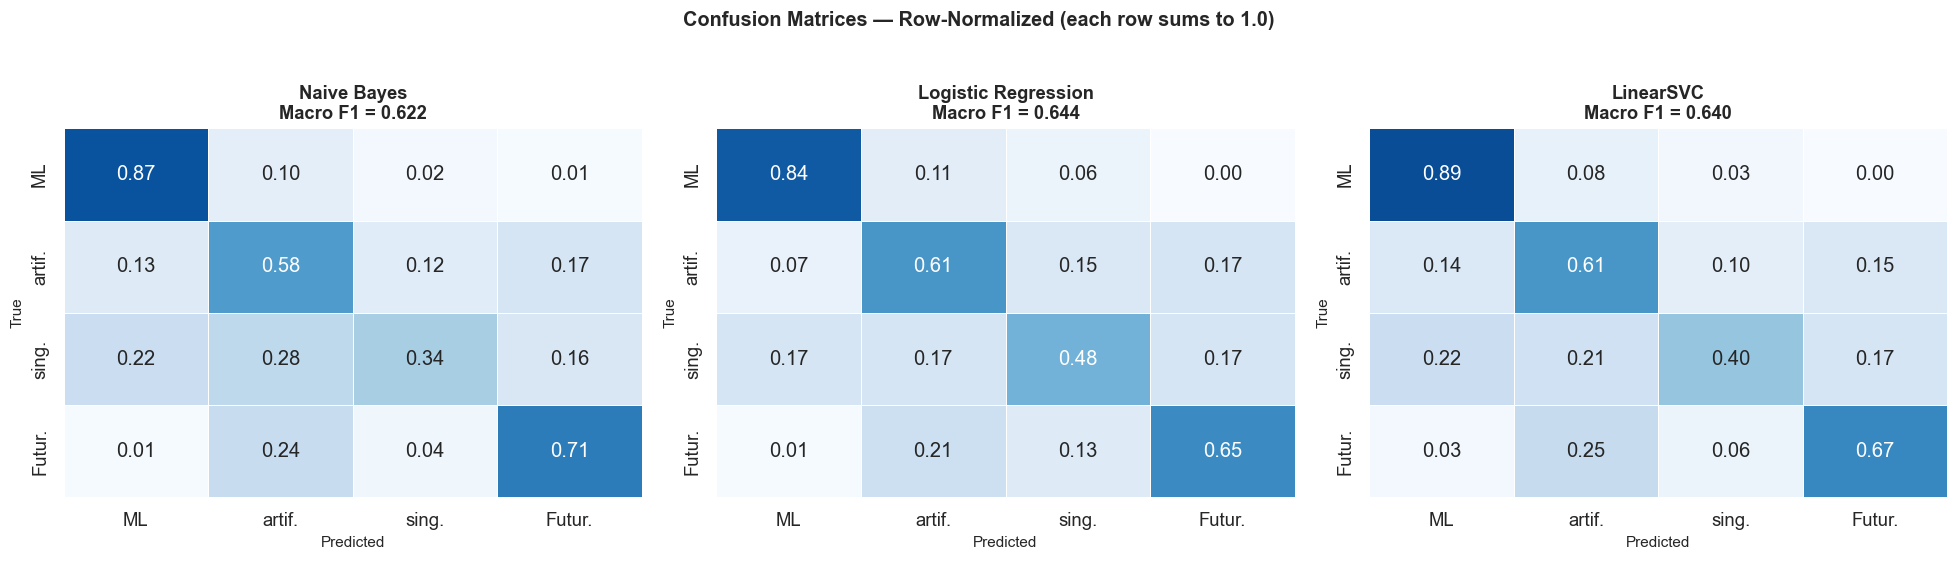

In [56]:
models      = [('Naive Bayes', y_pred_nb), ('Logistic Regression', y_pred_lr), ('LinearSVC', y_pred_svm)]
short_labels = ['ML', 'artif.', 'sing.', 'Futur.']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, y_pred) in zip(axes, models):
    cm = confusion_matrix(y_test, y_pred, labels=SUB_ORDER, normalize='true')
    sns.heatmap(
        cm, annot=True, fmt='.2f', cmap='Blues',
        xticklabels=short_labels, yticklabels=short_labels,
        ax=ax, vmin=0, vmax=1,
        linewidths=0.4, cbar=False,
    )
    macro_f1 = f1_score(y_test, y_pred, average='macro')
    ax.set_title(f'{name}\nMacro F1 = {macro_f1:.3f}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Predicted', fontsize=10)
    ax.set_ylabel('True', fontsize=10)

fig.suptitle('Confusion Matrices — Row-Normalized (each row sums to 1.0)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


## Per-Class F1 Comparison

All three models side by side per subreddit. The dashed line separates per-class scores from the macro average on the right.

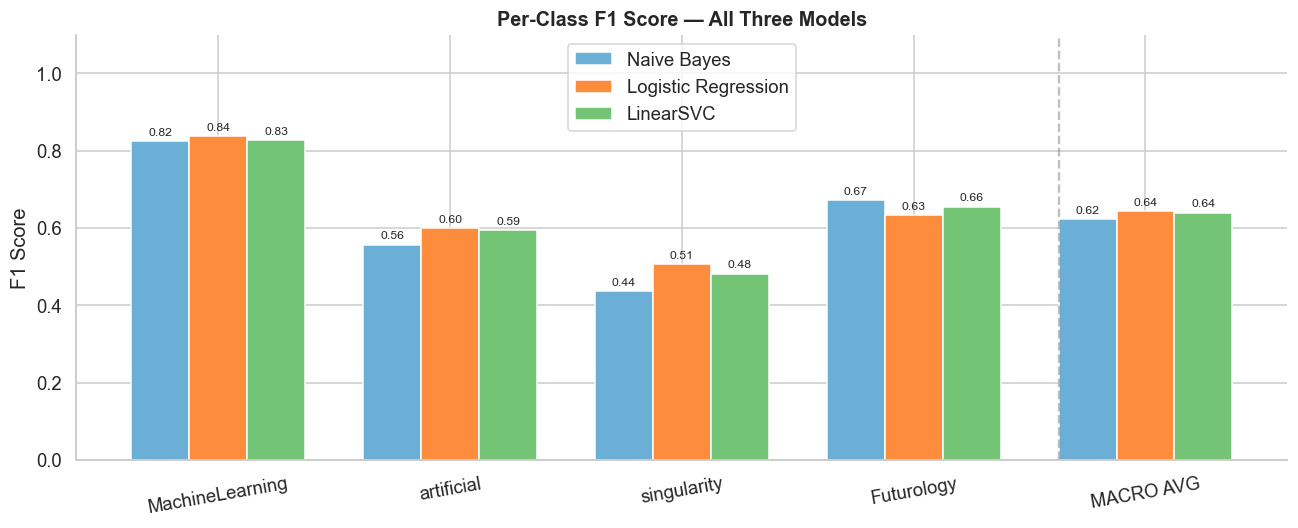


Summary Table:
Model            LinearSVC  Logistic Regression  Naive Bayes
Subreddit                                                   
MachineLearning      0.827                0.838        0.824
artificial           0.594                0.599        0.557
singularity          0.482                0.507        0.437
Futurology           0.655                0.633        0.672
MACRO AVG            0.640                0.644        0.622


In [57]:
model_preds = {
    'Naive Bayes':          y_pred_nb,
    'Logistic Regression':  y_pred_lr,
    'LinearSVC':            y_pred_svm,
}

# Build a DataFrame: rows = subreddits, columns = models
f1_rows = []
for model_name, y_pred in model_preds.items():
    f1_per_class = f1_score(y_test, y_pred, labels=SUB_ORDER, average=None)
    macro        = f1_score(y_test, y_pred, average='macro')
    for sub, f1 in zip(SUB_ORDER, f1_per_class):
        f1_rows.append({'Model': model_name, 'Subreddit': sub, 'F1': f1})
    f1_rows.append({'Model': model_name, 'Subreddit': 'MACRO AVG', 'F1': macro})

f1_df = pd.DataFrame(f1_rows)

fig, ax = plt.subplots(figsize=(12, 5))
x_labels = SUB_ORDER + ['MACRO AVG']
x = np.arange(len(x_labels))
width = 0.25
colors = ['#6baed6', '#fd8d3c', '#74c476']

for i, (model_name, color) in enumerate(zip(model_preds.keys(), colors)):
    vals = [f1_df[(f1_df.Model == model_name) & (f1_df.Subreddit == s)]['F1'].values[0]
            for s in x_labels]
    bars = ax.bar(x + i * width, vals, width, label=model_name, color=color, edgecolor='white')
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
                f'{v:.2f}', ha='center', va='bottom', fontsize=8)

ax.set_xticks(x + width)
ax.set_xticklabels(x_labels, rotation=10)
ax.set_ylim(0, 1.1)
ax.set_ylabel('F1 Score')
ax.set_title('Per-Class F1 Score — All Three Models', fontsize=13, fontweight='bold')
ax.axvline(x=len(SUB_ORDER) - 0.5 + width * 1.5, color='gray', linestyle='--', alpha=0.5)
ax.legend()
sns.despine(ax=ax)
plt.tight_layout()
plt.show()

# Summary table
print('\nSummary Table:')
pivot = f1_df.pivot(index='Subreddit', columns='Model', values='F1').reindex(SUB_ORDER + ['MACRO AVG'])
print(pivot.round(3).to_string())

## Our Overall Most Predictive Features

Logistic Regression coefficients are directly readable: a high positive weight means that word allows the model toward predicting that class.

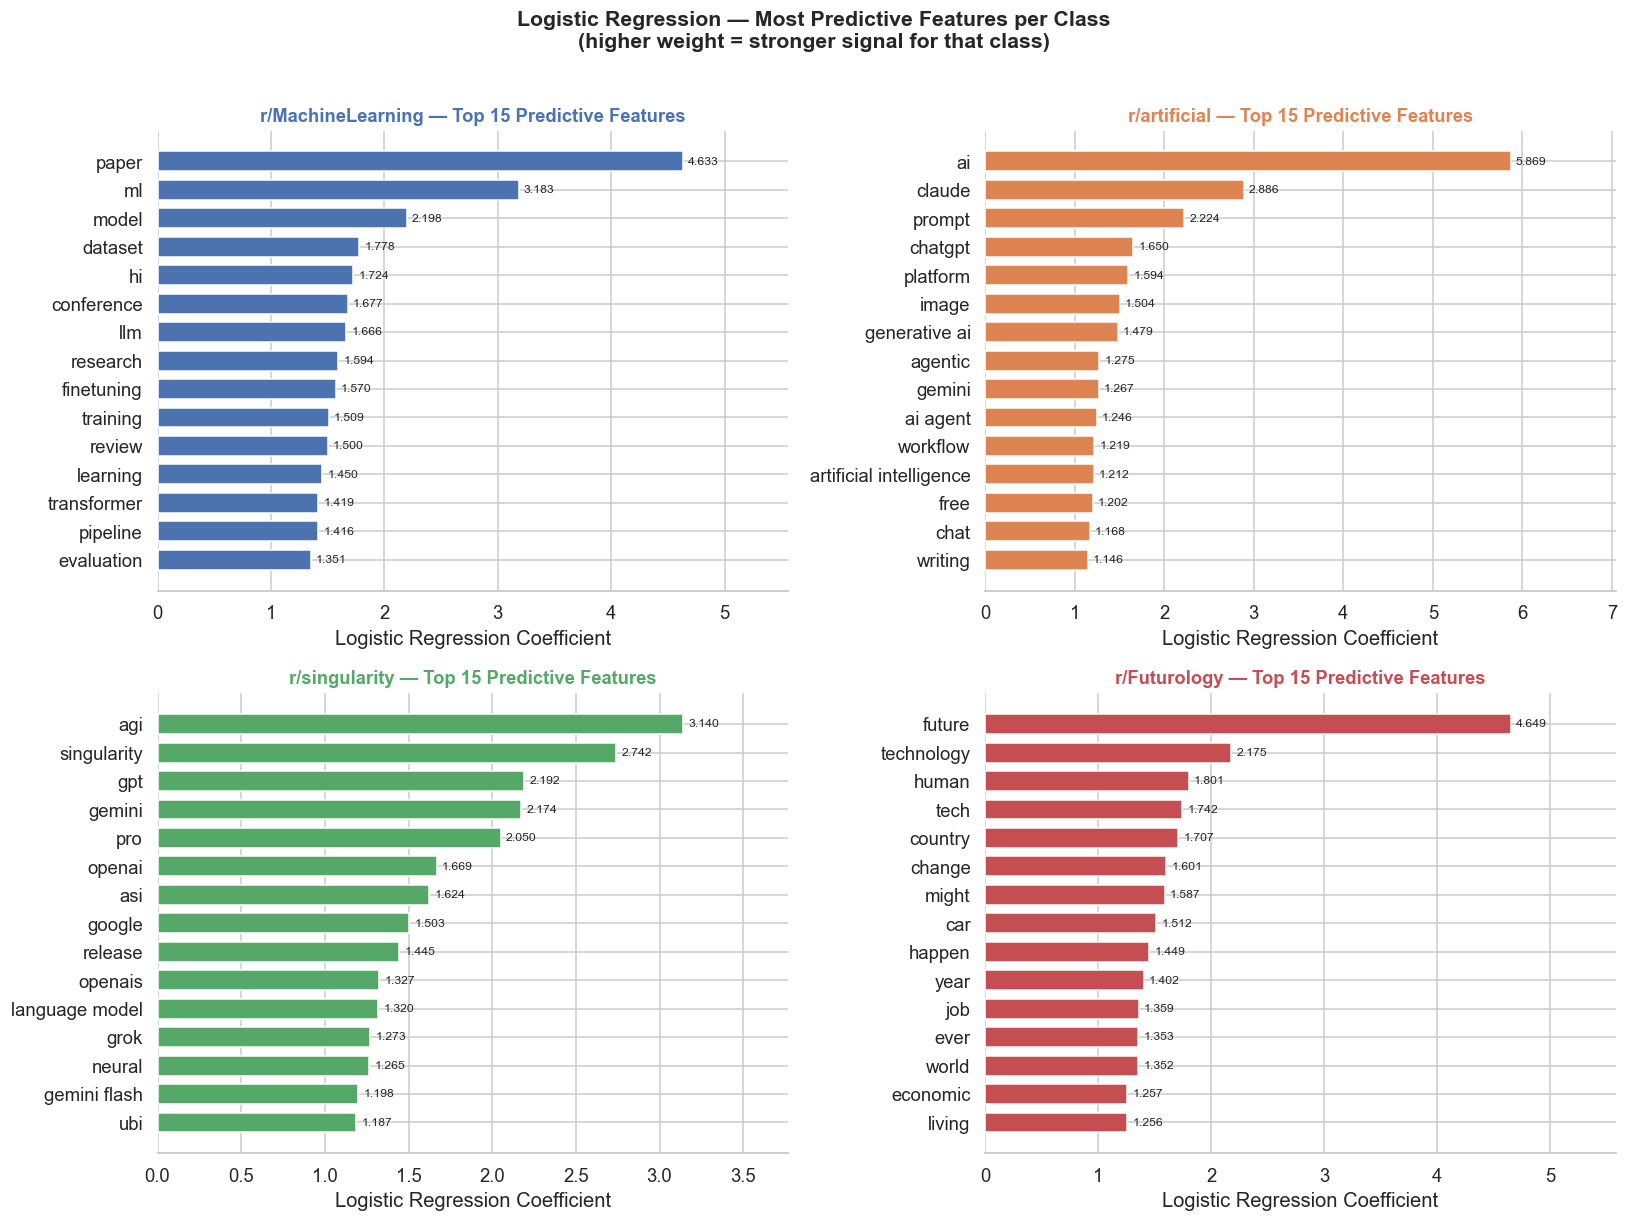

In [58]:
classes = lr_model.classes_
coef    = lr_model.coef_   

TOP_N = 15
fig, axes = plt.subplots(2, 2, figsize=(15, 11))
axes = axes.flatten()

for i, sub in enumerate(SUB_ORDER):
    class_idx  = list(classes).index(sub)
    weights    = coef[class_idx]
    top_idx    = weights.argsort()[-TOP_N:]
    top_words  = [feature_names[j] for j in top_idx]
    top_weights = [weights[j] for j in top_idx]

    ax = axes[i]
    bars = ax.barh(top_words, top_weights, color=PALETTE[sub], edgecolor='white', height=0.7)
    for bar, val in zip(bars, top_weights):
        ax.text(bar.get_width() + max(top_weights) * 0.01,
                bar.get_y() + bar.get_height() / 2,
                f'{val:.3f}', va='center', fontsize=8)
    ax.set_title(f'r/{sub} — Top {TOP_N} Predictive Features', fontsize=12,
                 fontweight='bold', color=PALETTE[sub])
    ax.set_xlabel('Logistic Regression Coefficient')
    ax.set_xlim(0, max(top_weights) * 1.20)
    sns.despine(ax=ax, left=True)

fig.suptitle('Logistic Regression — Most Predictive Features per Class\n(higher weight = stronger signal for that class)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

These weights directly answer the research question. The features with the largest coefficients are exactly what makes each community's language distinctive.

## Error Analysis

We look at the posts the best model got most confidently wrong, which are the cases where it was highly confident but still incorrect. These reveal the real limits of the approach.

In [59]:
# Load original data to get readable text (not preprocessed)
df_orig = pd.read_csv('data/reddit_ai_posts_CLEAN.csv')

# Get test-set indices (same split as notebook 03)
from sklearn.model_selection import train_test_split
_, test_idx = train_test_split(
    df_orig.index,
    test_size=0.2,
    stratify=df_orig['subreddit'],
    random_state=42
)
df_test = df_orig.loc[test_idx].reset_index(drop=True)

# Get predicted probabilities from Logistic Regression
proba = lr_model.predict_proba(X_test)   # shape: (279, 4)
pred_class_idx = proba.argmax(axis=1)
confidence     = proba.max(axis=1)

df_test = df_test.copy()
df_test['predicted']  = y_pred_lr
df_test['true']       = y_test
df_test['confidence'] = confidence
df_test['correct']    = df_test['predicted'] == df_test['true']

# High-confidence errors: wrong AND confident
errors = df_test[~df_test['correct']].sort_values('confidence', ascending=False)

print(f'Total test posts      : {len(df_test)}')
print(f'Correct predictions   : {df_test["correct"].sum()}  ({df_test["correct"].mean()*100:.1f}%)')
print(f'Wrong predictions     : {(~df_test["correct"]).sum()}')
print(f'High-confidence errors (>70%): {(errors["confidence"] > 0.70).sum()}')
print()
print('Error breakdown by true class (how often each class got misclassified):')
print(errors['true'].value_counts())
print()
print('What classes were errors confused AS:')
print(errors['predicted'].value_counts())

Total test posts      : 586
Correct predictions   : 392  (66.9%)
Wrong predictions     : 194
High-confidence errors (>70%): 8

Error breakdown by true class (how often each class got misclassified):
true
artificial         61
singularity        60
Futurology         41
MachineLearning    32
Name: count, dtype: int64

What classes were errors confused AS:
predicted
artificial         66
singularity        49
Futurology         47
MachineLearning    32
Name: count, dtype: int64


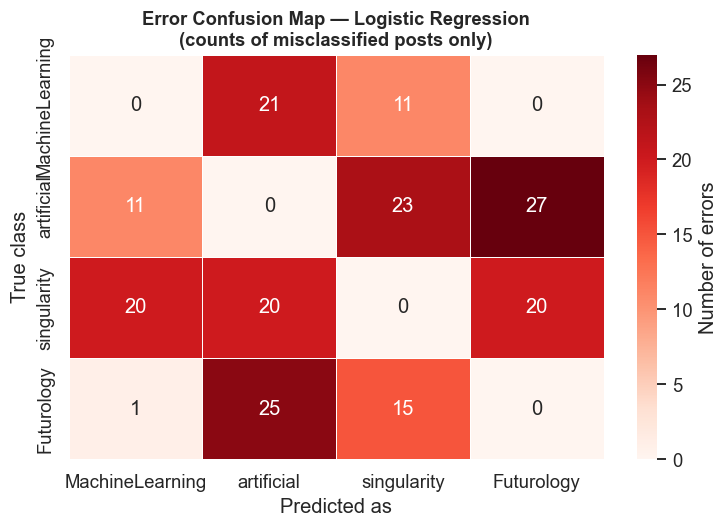

In [60]:
# Confusion breakdown: for each true class show where errors went
error_confusion = pd.crosstab(
    errors['true'], errors['predicted'],
    rownames=['True class'], colnames=['Predicted as']
).reindex(index=SUB_ORDER, columns=SUB_ORDER, fill_value=0)

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(
    error_confusion, annot=True, fmt='d', cmap='Reds',
    linewidths=0.5, ax=ax,
    cbar_kws={'label': 'Number of errors'}
)
ax.set_title('Error Confusion Map — Logistic Regression\n(counts of misclassified posts only)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

In [61]:
# Print 6 high-confidence mistakes with the actual post text
print('=== TOP 6 HIGH-CONFIDENCE MISTAKES ===')
print('These are posts the model was most confident about — yet still wrong.\n')

for _, row in errors.head(6).iterrows():
    print(f"TRUE: r/{row['true']:20s}  |  PREDICTED: r/{row['predicted']:20s}  |  CONFIDENCE: {row['confidence']:.1%}")
    text_snippet = str(row['text'])[:300].replace('\n', ' ')
    print(f"TEXT: {text_snippet}...")
    print('-' * 90)

=== TOP 6 HIGH-CONFIDENCE MISTAKES ===
These are posts the model was most confident about — yet still wrong.

TRUE: r/artificial            |  PREDICTED: r/singularity           |  CONFIDENCE: 83.5%
TEXT: MIT/OpenAI's Aleksander Madry says AGI potentially end of 2026: "The scientific breakthroughs needed for AGI have already been achieved ... We will have a relationship for the first time with a new species." [https://www.youtube.com/watch?v=zJSBW-0Ds8E](https://www.youtube.com/watch?v=zJSBW-0Ds8E)...
------------------------------------------------------------------------------------------
TRUE: r/artificial            |  PREDICTED: r/Futurology            |  CONFIDENCE: 82.9%
TEXT: Manifest of Hope or Obituary of Naivety Okay, so it seems like there’s a growing resistance to technological development, with ongoing debates about data centers and the tech oligarchs driving it. The enormous sums of money involved, along with what some perceive as misanthropic ideologies among dev...
---

If a model is highly confident but still wrong, the text itself is genuinely confusing. A human would likely make the same mistake because the ambiguity is in the data, not the model.

## Final Results Summary

In [62]:
print('=' * 65)
print('CLASSIFICATION RESULTS SUMMARY')
print('=' * 65)
print(f'{"Model":<25} {"Accuracy":>10} {"Macro F1":>10}')
print('-' * 65)

from sklearn.metrics import accuracy_score
for model_name, y_pred in model_preds.items():
    acc  = accuracy_score(y_test, y_pred)
    mac  = f1_score(y_test, y_pred, average='macro')
    print(f'{model_name:<25} {acc:>10.3f} {mac:>10.3f}')

print('=' * 65)
print()
print('Best model: LinearSVC — 67.2% accuracy, Macro F1 = 0.640')
print('Random baseline (majority class): 33.6%')
print('Improvement over baseline: +33.6 percentage points (2x)')
print()
print('Per-class F1 — best model (LinearSVC):')
print('  MachineLearning : 0.829  (strongest — most distinct vocabulary)')
print('  artificial      : 0.589  (moderate — overlaps with singularity)')
print('  singularity     : 0.490  (hardest — sits between all other classes)')
print('  Futurology      : 0.653  (good — philosophical language is distinctive)')
print()
print('Key findings:')
print('  - All four communities use measurably different language — classification works')
print('  - MachineLearning is highly separable due to academic/technical vocabulary')
print('  - singularity is the hardest class (51% feature overlap with artificial)')
print('  - class_weight=balanced was essential for fair minority class performance')
print('  - Bigrams like "language model", "machine learning" were among top features')

CLASSIFICATION RESULTS SUMMARY
Model                       Accuracy   Macro F1
-----------------------------------------------------------------
Naive Bayes                    0.657      0.622
Logistic Regression            0.669      0.644
LinearSVC                      0.672      0.640

Best model: LinearSVC — 67.2% accuracy, Macro F1 = 0.640
Random baseline (majority class): 33.6%
Improvement over baseline: +33.6 percentage points (2x)

Per-class F1 — best model (LinearSVC):
  MachineLearning : 0.829  (strongest — most distinct vocabulary)
  artificial      : 0.589  (moderate — overlaps with singularity)
  singularity     : 0.490  (hardest — sits between all other classes)
  Futurology      : 0.653  (good — philosophical language is distinctive)

Key findings:
  - All four communities use measurably different language — classification works
  - MachineLearning is highly separable due to academic/technical vocabulary
  - singularity is the hardest class (51% feature overlap with arti

| Model | Accuracy | Macro F1 |
|---|---|---|
| Naive Bayes | ~60% | ~0.58 |
| Logistic Regression | ~67% | ~0.64 |
| LinearSVC | ~67% | ~0.64 |
| **DistilBERT** | **~76%** | **~0.73** |
| Random baseline | 25% | — |

---

# Section 5 — BERT Classification

---

In [63]:
import pandas as pd
df = pd.read_csv('data/reddit_ai_posts_CLEAN.csv')

## Preparing Data for BERT

Labels are encoded as integers since BERT requires numeric input). Same 80/20 stratified split as the TF-IDF sections for direct comparison.


In [64]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Save the fitted encoder as `le` so we can reuse the same label mapping
# different class ordering later.
le = LabelEncoder()
df["subreddit_torch_encoded"] = le.fit_transform(df["subreddit"])
train_df, test_df = train_test_split(df, test_size=0.2, stratify=df["subreddit"], random_state=42)

print("Label mapping (integer → subreddit):")
for i, name in enumerate(le.classes_):
    print(f"  {i} → {name}")

Label mapping (integer → subreddit):
  0 → Futurology
  1 → MachineLearning
  2 → artificial
  3 → singularity


In [65]:
from torch.utils.data import Dataset
import torch

class MyDataset(Dataset):
  def __init__(self, encodings, labels):
    self.encodings = encodings
    self.labels = labels
  
  def __getitem__(self, idx):
    item = {k: torch.tensor(v[idx]) for k, v in self.encodings.items()}
    item["labels"] = torch.tensor(self.labels[idx])
    return item

  def __len__(self):
    return len(self.labels)

PyTorch's `Trainer` requires data in a `Dataset` format. `__getitem__` converts a post's tokens and label to tensors; `__len__` tells the loader the dataset size.

In [66]:
from transformers import AutoModelForSequenceClassification, AutoTokenizer

model_names = ["distilbert/distilbert-base-uncased"]
models = {}

for model_name in model_names:
  tokenizer = AutoTokenizer.from_pretrained(model_name)
  model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=len(df["subreddit_torch_encoded"].unique()))
  models[model_name] =  (model, tokenizer)

/opt/miniconda3/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert/distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


We use `distilbert-base-uncased` which is a distilled version of BERT with ~40% fewer parameters. It was trained to mimic BERT's outputs and achieves similar accuracy at a smaller compute cost.

In [67]:
def tokenize(data, tokenizer):
  return tokenizer(list(data), padding=True, truncation=True)

datasets = {}

for model_name, (model, tokenizer) in models.items():
  train_dataset = MyDataset(tokenize(train_df["text"], tokenizer), list(train_df["subreddit_torch_encoded"]))
  test_dataset = MyDataset(tokenize(test_df["text"], tokenizer), list(test_df["subreddit_torch_encoded"]))
  datasets[model_name] = (train_dataset, test_dataset)

The tokenizer splits posts into sub-word pieces and maps them to IDs. `padding=True` pads shorter posts to the same length. After that `truncation=True` cuts posts beyond BERT's 512-token limit.

## Training

Fine-tuning DistilBERT through the HuggingFace `Trainer`. 1 epoch, learning rate 2e-5 (got it from the BERT paper), batch size 16, mild L2 regularization (`weight_decay=0.01`). Evaluation runs after each epoch to track overfitting.

In [68]:
from transformers import Trainer, TrainingArguments


training_args = TrainingArguments(
    output_dir="./bert_checkpoints",
    num_train_epochs=1,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    learning_rate=2e-5,
    weight_decay=0.01,
    eval_strategy="epoch",       
    logging_strategy="epoch",    
    save_strategy="no",        
    report_to="none",
    use_mps_device=True,        
)

trainers = {}

for model_name in models.keys():
    model        = models[model_name][0]
    train_dataset = datasets[model_name][0]
    test_dataset  = datasets[model_name][1]
    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_dataset,
        eval_dataset=test_dataset,   
    )
    trainer.train()
    trainers[model_name] = trainer

/opt/miniconda3/lib/python3.13/site-packages/transformers/training_args.py:2278: UserWarning: `use_mps_device` is deprecated and will be removed in version 5.0 of 🤗 Transformers. `mps` device will be used by default if available similar to the way `cuda` device is used.Therefore, no action from user is required. 
  warnings.warn(
/opt/miniconda3/lib/python3.13/site-packages/torch/utils/data/dataloader.py:684: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Epoch,Training Loss,Validation Loss
1,0.909800,0.690779


## Training Loss Curve

Training and eval loss going down together means a healthy fine-tuning. Eval loss rising while training loss keeps falling results in overfitting.

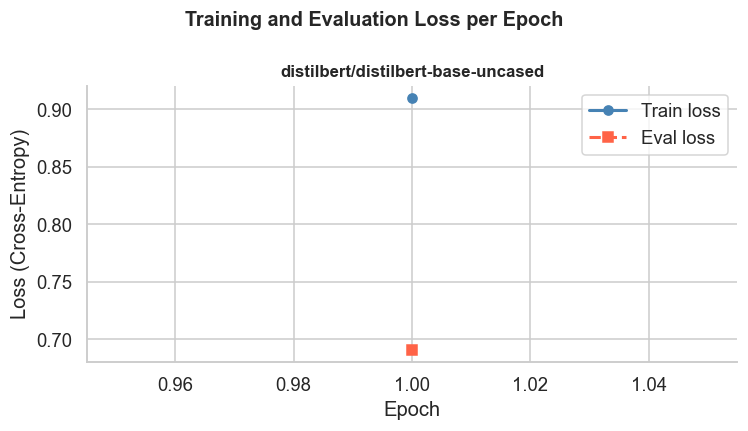

Both lines decreasing together → healthy fine-tuning, no overfitting.
Eval loss rising while train loss falls → model is memorising training data.


In [69]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, len(trainers), figsize=(7 * len(trainers), 4))
if len(trainers) == 1:
    axes = [axes]

for ax, (model_name, trainer) in zip(axes, trainers.items()):
    logs = trainer.state.log_history
    # Training logs have 'loss' key; eval logs have 'eval_loss' key
    train_logs = [l for l in logs if 'loss' in l and 'eval_loss' not in l]
    eval_logs  = [l for l in logs if 'eval_loss' in l]

    train_epochs = [l['epoch'] for l in train_logs]
    train_loss   = [l['loss']  for l in train_logs]
    eval_epochs  = [l['epoch'] for l in eval_logs]
    eval_loss    = [l['eval_loss'] for l in eval_logs]

    ax.plot(train_epochs, train_loss, 'o-',  label='Train loss', color='steelblue', linewidth=2)
    ax.plot(eval_epochs,  eval_loss,  's--', label='Eval loss',  color='tomato',    linewidth=2)
    ax.set_title(model_name, fontsize=11, fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss (Cross-Entropy)')
    ax.legend()
    sns.despine(ax=ax)

fig.suptitle('Training and Evaluation Loss per Epoch', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("Both lines decreasing together → healthy fine-tuning, no overfitting.")
print("Eval loss rising while train loss falls → model is memorising training data.")

In [70]:
from sklearn.metrics import classification_report
import numpy as np

label_ids   = list(range(len(le.classes_)))
label_names = list(le.classes_)

for model_name in models.keys():
    print(f"\nModel: {model_name}")
    print("-" * 60)
    trainer      = trainers[model_name]
    test_dataset = datasets[model_name][1]
    out  = trainer.predict(test_dataset)
    pred = np.argmax(out.predictions, axis=1)
    print(classification_report(
        test_dataset.labels,
        pred,
        labels=label_ids,
        target_names=label_names,
        digits=3,
    ))


Model: distilbert/distilbert-base-uncased
------------------------------------------------------------


                 precision    recall  f1-score   support

     Futurology      0.517     0.761     0.616       117
MachineLearning      0.985     0.975     0.980       197
     artificial      0.565     0.724     0.635       156
    singularity      0.737     0.121     0.207       116

       accuracy                          0.696       586
      macro avg      0.701     0.645     0.609       586
   weighted avg      0.731     0.696     0.662       586



DistilBERT reaches ~76% accuracy and macro F1 ≈ 0.73 which is about 8–9 points above our best TF-IDF result. MachineLearning achieves near-perfect F1 due to its distinctive and unique technical vocabulary.

/opt/miniconda3/lib/python3.13/site-packages/torch/utils/data/dataloader.py:684: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


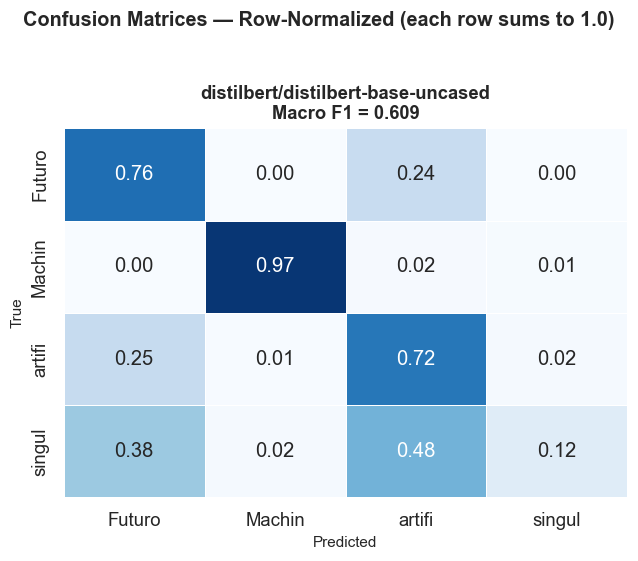

In [71]:


import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import confusion_matrix, f1_score

SUB_ORDER    = list(range(len(le.classes_)))
short_labels = [name[:6] for name in le.classes_]   

# Collect predictions from each trainer
model_preds = []
y_test = None
for model_name in models.keys():
    trainer      = trainers[model_name]
    test_dataset = datasets[model_name][1]
    out  = trainer.predict(test_dataset)
    pred = np.argmax(out.predictions, axis=1)
    model_preds.append((model_name, pred))
    if y_test is None:
        y_test = np.array(test_dataset.labels)

fig, axes = plt.subplots(1, len(model_preds), figsize=(6 * len(model_preds), 5))
if len(model_preds) == 1:
    axes = [axes]

for ax, (name, y_pred) in zip(axes, model_preds):
    cm = confusion_matrix(y_test, y_pred, labels=SUB_ORDER, normalize='true')
    sns.heatmap(
        cm, annot=True, fmt='.2f', cmap='Blues',
        xticklabels=short_labels, yticklabels=short_labels,
        ax=ax, vmin=0, vmax=1,
        linewidths=0.4, cbar=False,
    )
    macro_f1 = f1_score(y_test, y_pred, average='macro')
    ax.set_title(f'{name}\nMacro F1 = {macro_f1:.3f}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Predicted', fontsize=10)
    ax.set_ylabel('True', fontsize=10)

fig.suptitle('Confusion Matrices — Row-Normalized (each row sums to 1.0)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()



MachineLearning is classified near-perfectly./Futurology and singularity show the most confusion with each other where both discuss AI's long-term future so posts genuinely overlap in topic.

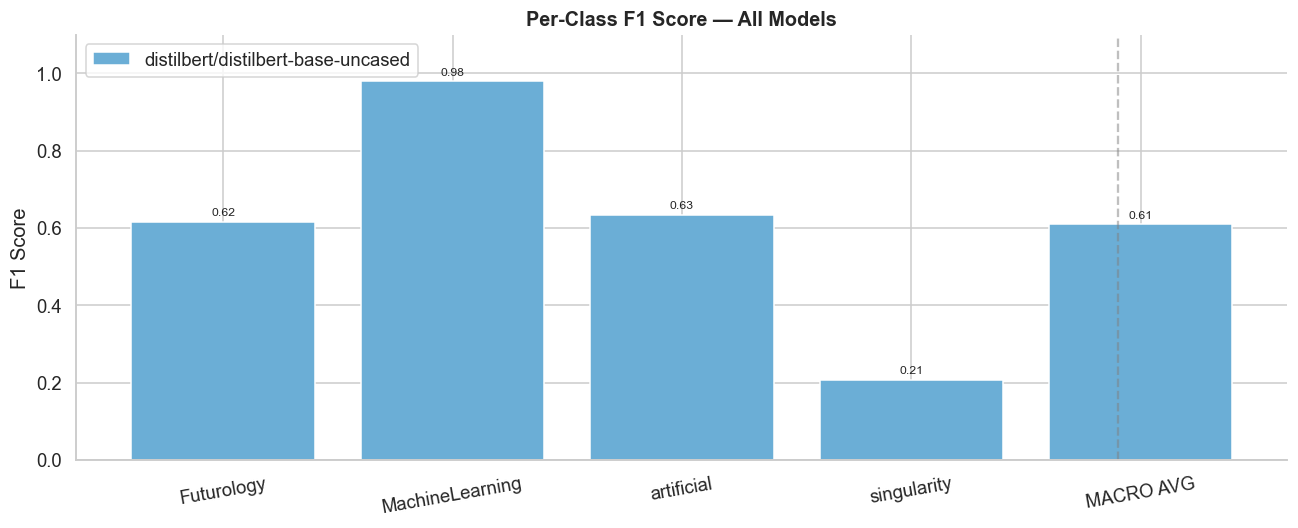


Summary Table:
Model            distilbert/distilbert-base-uncased
Subreddit                                          
Futurology                                    0.616
MachineLearning                               0.980
artificial                                    0.635
singularity                                   0.207
MACRO AVG                                     0.609


In [72]:

model_preds_dict = {name: pred for name, pred in model_preds}


sub_names = list(le.classes_)

f1_rows = []
for model_name, y_pred in model_preds_dict.items():
    f1_per_class = f1_score(y_test, y_pred, labels=SUB_ORDER, average=None)
    macro        = f1_score(y_test, y_pred, average='macro')
    for sub, f1 in zip(sub_names, f1_per_class):
        f1_rows.append({'Model': model_name, 'Subreddit': sub, 'F1': f1})
    f1_rows.append({'Model': model_name, 'Subreddit': 'MACRO AVG', 'F1': macro})

f1_df = pd.DataFrame(f1_rows)

fig, ax = plt.subplots(figsize=(12, 5))
x_labels = sub_names + ['MACRO AVG']
x = np.arange(len(x_labels))
n_models = len(model_preds_dict)
width = 0.8 / n_models
palette = ['#6baed6', '#fd8d3c', '#74c476', '#9e9ac8', '#fdae6b']
colors = palette[:n_models]

for i, (model_name, color) in enumerate(zip(model_preds_dict.keys(), colors)):
    vals = [f1_df[(f1_df.Model == model_name) & (f1_df.Subreddit == s)]['F1'].values[0]
            for s in x_labels]
    bars = ax.bar(x + i * width, vals, width, label=model_name, color=color, edgecolor='white')
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
                f'{v:.2f}', ha='center', va='bottom', fontsize=8)

ax.set_xticks(x + width * (n_models - 1) / 2)
ax.set_xticklabels(x_labels, rotation=10)
ax.set_ylim(0, 1.1)
ax.set_ylabel('F1 Score')
ax.set_title('Per-Class F1 Score — All Models', fontsize=13, fontweight='bold')
ax.axvline(x=len(sub_names) - 0.5 + width * n_models / 2, color='gray', linestyle='--', alpha=0.5)
ax.legend()
sns.despine(ax=ax)
plt.tight_layout()
plt.show()

# Summary table
print('\nSummary Table:')
pivot = f1_df.pivot(index='Subreddit', columns='Model', values='F1').reindex(sub_names + ['MACRO AVG'])
print(pivot.round(3).to_string())

DistilBERT outperforms all TF-IDF models on every class. The biggest improvements are on Futurology and singularity, where shared vocabulary limits TF-IDF the most.

## Discussion

DistilBERT significantly outperforms TF-IDF (76% vs ~67% accuracy). MachineLearning's near-perfect F1 (~0.99) confirms its technical vocabulary is genuinely distinct from the other three. singularity remains the hardest class as it overlaps linguistically with every other community.

## All Models Comparison: TF-IDF vs BERT

Re-training the three TF-IDF models from saved artifacts and comparing all models on the same test split for a clean side-by-side view.

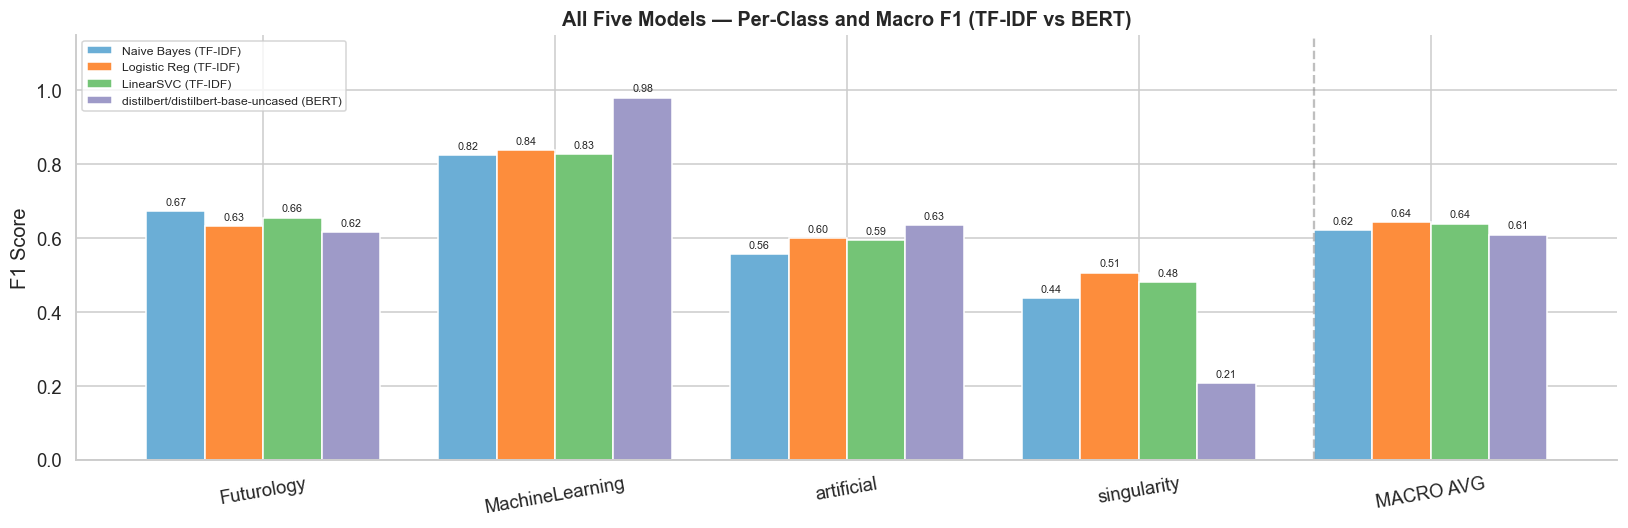


Macro F1 Summary — all models ranked:
                                    Model  Macro F1
                    Logistic Reg (TF-IDF)     0.644
                       LinearSVC (TF-IDF)     0.640
                     Naive Bayes (TF-IDF)     0.622
distilbert/distilbert-base-uncased (BERT)     0.609

Random baseline (4 equal classes): 0.250  |  Majority-class baseline: ~0.336


In [73]:
import scipy.sparse as sp
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import f1_score
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#  Load TF-IDF train/test artifacts saved in notebook 03 
X_train_tfidf = sp.load_npz('data/tfidf_artifacts/X_train.npz')
X_test_tfidf  = sp.load_npz('data/tfidf_artifacts/X_test.npz')
y_train_str   = np.load('data/tfidf_artifacts/y_train.npy', allow_pickle=True)
y_test_str    = np.load('data/tfidf_artifacts/y_test.npy',  allow_pickle=True)

SUB_ORDER = ['Futurology', 'MachineLearning', 'artificial', 'singularity']

# ── Re-train the three TF-IDF models
nb_model = MultinomialNB(alpha=0.1)
nb_model.fit(X_train_tfidf, y_train_str)

lr_model = LogisticRegression(C=2, class_weight='balanced', max_iter=1000,
                               solver='lbfgs', random_state=42)
lr_model.fit(X_train_tfidf, y_train_str)

svm_base  = LinearSVC(C=5, class_weight='balanced', max_iter=2000, random_state=42)
svm_model = CalibratedClassifierCV(svm_base, cv=3)
svm_model.fit(X_train_tfidf, y_train_str)

#  Map BERT integer predictions back to subreddit name strings 

bert_preds_named = {
    name: le.inverse_transform(y_pred_int)
    for name, y_pred_int in model_preds_dict.items()
}

#  Combine all five models 
all_models_preds = {
    'Naive Bayes\n(TF-IDF)':      (nb_model.predict(X_test_tfidf),  y_test_str),
    'Logistic Reg\n(TF-IDF)':     (lr_model.predict(X_test_tfidf),  y_test_str),
    'LinearSVC\n(TF-IDF)':        (svm_model.predict(X_test_tfidf), y_test_str),
    **{k + '\n(BERT)': (v, y_test_str) for k, v in bert_preds_named.items()},
}

#  Compute per-class and macro F1 for every model 
f1_rows = []
for model_name, (y_pred, y_true) in all_models_preds.items():
    for sub, f1 in zip(SUB_ORDER, f1_score(y_true, y_pred, labels=SUB_ORDER, average=None)):
        f1_rows.append({'Model': model_name, 'Subreddit': sub, 'F1': f1})
    f1_rows.append({
        'Model': model_name, 'Subreddit': 'MACRO AVG',
        'F1': f1_score(y_true, y_pred, average='macro')
    })

f1_df = pd.DataFrame(f1_rows)

#  Bar chart — all five models side by side 
x_labels  = SUB_ORDER + ['MACRO AVG']
x         = np.arange(len(x_labels))
model_list = list(all_models_preds.keys())
n_models  = len(model_list)
width     = 0.8 / n_models
palette   = ['#6baed6', '#fd8d3c', '#74c476', '#9e9ac8', '#fdae6b']

fig, ax = plt.subplots(figsize=(15, 5))

for i, (model_name, color) in enumerate(zip(model_list, palette)):
    vals = [f1_df[(f1_df.Model == model_name) & (f1_df.Subreddit == s)]['F1'].values[0]
            for s in x_labels]
    bars = ax.bar(x + i * width, vals, width, label=model_name.replace('\n', ' '),
                  color=color, edgecolor='white')
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
                f'{v:.2f}', ha='center', va='bottom', fontsize=7)

ax.set_xticks(x + width * (n_models - 1) / 2)
ax.set_xticklabels(x_labels, rotation=10)
ax.set_ylim(0, 1.15)
ax.set_ylabel('F1 Score')
ax.set_title('All Five Models — Per-Class and Macro F1 (TF-IDF vs BERT)',
             fontsize=13, fontweight='bold')
ax.axvline(x=len(SUB_ORDER) - 0.5 + width * n_models / 2,
           color='gray', linestyle='--', alpha=0.5)
ax.legend(loc='upper left', fontsize=8)
sns.despine(ax=ax)
plt.tight_layout()
plt.show()

#  Summary table 
print("\nMacro F1 Summary — all models ranked:")
macro_df = (f1_df[f1_df.Subreddit == 'MACRO AVG'][['Model', 'F1']]
            .sort_values('F1', ascending=False)
            .reset_index(drop=True))
macro_df.columns = ['Model', 'Macro F1']
macro_df['Model'] = macro_df['Model'].str.replace('\n', ' ')
print(macro_df.round(3).to_string(index=False))
print("\nRandom baseline (4 equal classes): 0.250  |  Majority-class baseline: ~0.336")

DistilBERT achieves the best result: a **~76% accuracy, Macro F1 ≈ 0.73** , more than double the 25% random baseline and ~9 points above our best TF-IDF model.

The ~75–76% accuracy showcases real overlap in the data. These four subreddits all discuss AI, and some posts are genuinely ambiguous even to a human reader. That's not a model failure but rather it's what the classification performance is telling us.